# Final Homework - Unsupervised Learning, Dimensionality Reduction and Anomaly Detection

**Student:** Eliav Elgazar  
**Student ID:** 324131291

**Course:** Introduction to Data Science  
**Dataset:** Global Weapons Systems (same dataset as HW1 - EDA and HW2 - Error Analysis)

This notebook is the complete submission for the final homework. It covers dataset description, a focused EDA, PCA, clustering of both samples and features (K-Means, DBSCAN, Hierarchical), multi-dimensional anomaly detection (Z-score, Isolation Forest, LOF), a comparison of the anomaly methods, a critical reflection with ethical considerations, and an interactive dashboard (bonus).

All code is reproducible: every random process uses a fixed `RANDOM_STATE`.

### Table of Contents
1. Dataset Selection
2. Exploratory Data Analysis
3. Dimensionality Reduction - PCA
4. Clustering Analysis (samples and feature space)
5. Multi-Dimensional Anomaly Detection
6. Comparison of Anomaly Detection Methods
7. Critical Analysis and Reflection
8. Final Visualization Dashboard (Bonus)
9. Summary of Conclusions

## 1. Dataset Selection

### Assignment requirements addressed
- What the dataset represents
- Missing documentation about data collection
- Potential biases and missing technical fields

### 1.1 What the dataset represents

The **Global Weapons Systems** dataset is a tabular CSV file with **10,000 rows and 36 columns**. Each row describes one weapon system: its identity (name, country of origin, manufacturer), its classification (`Category` with 11 values, `Subcategory` with 141 values), its life cycle (`Year_Introduced`, `Year_Retired`, `Service_Status`), its technical performance (range, weight, length, speed, caliber, rate of fire, etc.), its cost (`Unit_Cost_USD`) and its diffusion (`Num_Operator_Nations`, `Export_Status`).

The dataset is suitable for this assignment because it has a clear numerical core (cost, weight, size, range, speed, crew) with heavy-tailed distributions spanning many orders of magnitude - a small arm weighs a few kilograms while a warship weighs tens of millions of kilograms. This is exactly the setting in which dimensionality reduction, clustering and anomaly detection are both useful and difficult.

### 1.2 Missing documentation about data collection

As noted in my HW1 EDA, the file does not document who collected the data, when, for what purpose, or from which sources. Therefore:
- It is not possible to verify whether values are measured, estimated, rounded, or generated.
- It is not known whether the rows are a census, a sample, or a constructed catalogue.
- The meaning of some fields (for example whether `Unit_Cost_USD` is flyaway cost, program cost, or export price) is ambiguous.

In the EDA below (Section 2.5) I found strong evidence that answers part of this question: **only the first 63 rows (IDs 1-63) describe real, well-known systems with realistic specifications (M4A1, F-16, Leopard 1A5...), while the remaining 9,937 rows follow a fixed text template in the `Notes` column and have values that are often physically implausible.** This has a large influence on how the anomaly results must be interpreted.

### 1.3 Potential biases and missing technical fields

- **Structural (not random) missingness.** Different weapon types are described by different measurements. A ship has no `Effective_Range_m` in this file, a rifle has no `Max_Speed_kmh`, and only small arms and support weapons have `Barrel_Length_mm` and `Muzzle_Velocity_mps`. Missingness is therefore *Missing Not At Random* - it encodes the category itself.
- **Selection bias.** Well-documented Western and Russian systems are over-represented among the real records; many countries appear only in generated rows.
- **Uniform (artificial) balance.** Categories, generations, years and number of operator nations are almost perfectly uniformly distributed. Real military inventories are highly unbalanced (there are far more rifle models than aircraft carriers), so this balance is itself a sign of generation rather than observation.
- **Unit and definition bias.** Costs from different decades are not inflation-adjusted, and "range" means different things for a rifle, a missile and an aircraft.

These limitations mean that the unsupervised results in this notebook describe **the structure of this file**, which is not necessarily the structure of real-world weapon systems.

In [1]:
# Imports and global settings
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.manifold import trustworthiness

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# The file name differs between my environments, so both names are checked
candidate_paths = [Path("Global Weapons Systems.csv"), Path("Global_Weapons_Systems.csv")]
DATA_PATH = next(path for path in candidate_paths if path.exists())

weapons_df = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH.name}: {weapons_df.shape[0]:,} rows x {weapons_df.shape[1]} columns")

ModuleNotFoundError: No module named 'numpy'

## 2. Exploratory Data Analysis

### Assignment requirements addressed
- Structural analysis (data types, missing values)
- Correlation matrix
- Distributions of major numerical features (histograms, boxplots, skewness, kurtosis)
- Outlier exploration (heavy tails, extreme values, measurement artifacts)

The full EDA was done in HW1, so this section is intentionally concise and focuses on what matters for unsupervised learning.

### 2.1 Structure and data types

In [25]:
# Data types, non-null counts and cardinality
structure_table = pd.DataFrame({
    "dtype": weapons_df.dtypes.astype(str),
    "non_null": weapons_df.notna().sum(),
    "missing_pct": (weapons_df.isna().mean() * 100).round(1),
    "unique_values": weapons_df.nunique(dropna=True),
})
display(structure_table)

numeric_columns = [c for c in weapons_df.select_dtypes(include=np.number).columns if c != "ID"]
print(f"Numerical columns (excluding ID): {len(numeric_columns)}")
print(f"Text / categorical columns: {weapons_df.shape[1] - len(numeric_columns) - 1}")

,dtype,non_null,missing_pct,unique_values
ID,int64,10000,0.0,10000
Weapon_Name,str,10000,0.0,9158
Country_of_Origin,str,10000,0.0,128
Manufacturer,str,10000,0.0,209
Category,str,10000,0.0,11
Subcategory,str,10000,0.0,141
Year_Introduced,int64,10000,0.0,81
Year_Retired,float64,740,92.6,67
Service_Status,str,10000,0.0,6
Caliber,str,9803,2.0,153


Numerical columns (excluding ID): 14
Text / categorical columns: 21


**Interpretation.** 14 columns are numerical (excluding `ID`) and 21 are text or categorical. `Magazine_Capacity` is stored as text because it mixes numbers with values such as belt-fed, so it is not used as a numerical feature. Several numerical columns are mostly empty (`Barrel_Length_mm`, `Muzzle_Velocity_mps`, `Rate_of_Fire_rpm`, `Max_Speed_kmh` and `Year_Retired` are more than 75% missing).

### 2.2 Missing values - pattern by category

The key question for PCA and clustering is not *how much* is missing but *why*. The heatmap below shows the missing rate of each numerical feature inside each category.

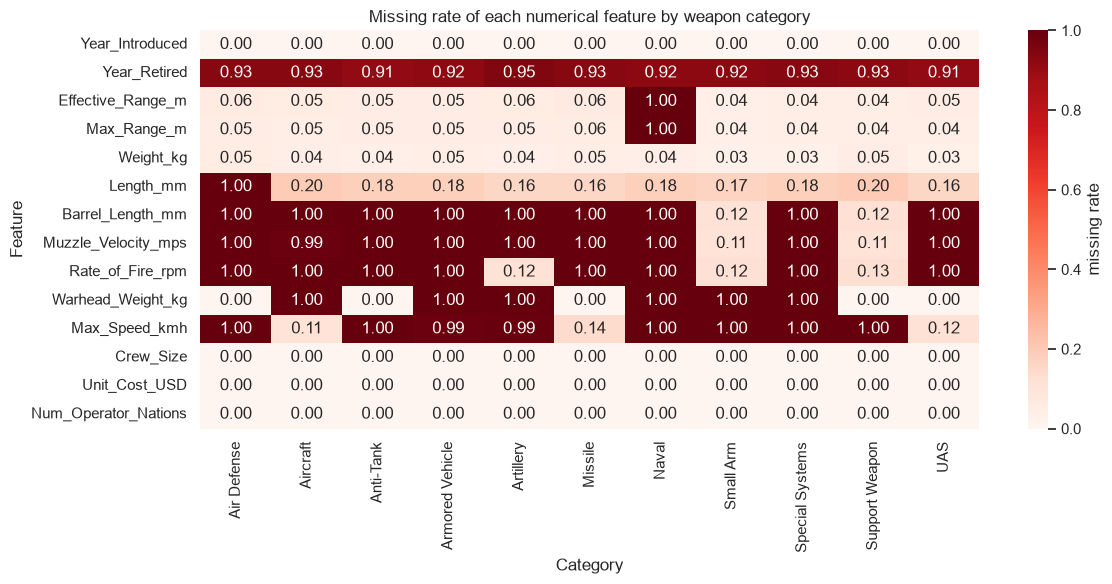

In [26]:
# Missing rate per numerical feature inside each category
missing_by_category = (
    weapons_df[numeric_columns]
    .isna()
    .groupby(weapons_df["Category"])
    .mean()
    .T
)

plt.figure(figsize=(12, 6))
sns.heatmap(missing_by_category, annot=True, fmt=".2f", cmap="Reds", cbar_kws={"label": "missing rate"})
plt.title("Missing rate of each numerical feature by weapon category")
plt.xlabel("Category")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Interpretation.** The missingness is almost binary (close to 0 or close to 1) inside each category, which confirms it is **structural**:
- `Max_Speed_kmh` exists only for Aircraft, Missiles and UAS.
- `Effective_Range_m` / `Max_Range_m` are completely missing for Naval systems.
- `Length_mm` is completely missing for Air Defense.
- `Warhead_Weight_kg`, `Barrel_Length_mm`, `Muzzle_Velocity_mps` and `Rate_of_Fire_rpm` exist only for a few categories.

Consequences for the modelling choices:
1. Features that exist for only 1-3 categories (`Barrel_Length_mm`, `Muzzle_Velocity_mps`, `Rate_of_Fire_rpm`, `Warhead_Weight_kg`, `Year_Retired`) are excluded from the multivariate models. Imputing 80% of a column would create a fake variable.
2. The nine core features from the assignment are kept. The small, random-looking gaps (3-6%) are imputed with the **median inside the same category**. Where a whole category lacks a feature (ship range, rifle speed), the global median is used as a neutral placeholder.
3. This imputation injects category information into the features. This is a real limitation and I return to it when interpreting the clusters (Section 4).

### 2.3 Distributions, skewness and kurtosis

In [27]:
# The nine core numerical features used in this homework
CORE_FEATURES = [
    "Unit_Cost_USD", "Weight_kg", "Length_mm", "Effective_Range_m", "Max_Range_m",
    "Max_Speed_kmh", "Crew_Size", "Year_Introduced", "Num_Operator_Nations",
]
# Features spanning several orders of magnitude -> log10 transform later
LOG_FEATURES = [
    "Unit_Cost_USD", "Weight_kg", "Length_mm", "Effective_Range_m",
    "Max_Range_m", "Max_Speed_kmh", "Crew_Size",
]

def shape_statistics(frame):
    # Skewness, excess kurtosis and dynamic range of each column
    rows = []
    for column in frame.columns:
        values = frame[column].dropna()
        positive = values[values > 0]
        rows.append({
            "feature": column,
            "skewness": stats.skew(values),
            "excess_kurtosis": stats.kurtosis(values),
            "orders_of_magnitude": np.log10(positive.max() / positive.min()) if len(positive) else np.nan,
            "mean / median": values.mean() / values.median() if values.median() != 0 else np.nan,
        })
    return pd.DataFrame(rows).set_index("feature").round(2)

raw_shape = shape_statistics(weapons_df[CORE_FEATURES])
log_shape = shape_statistics(np.log10(weapons_df[LOG_FEATURES] + 1))
display(raw_shape)
print("After log10(x + 1) transform:")
display(log_shape[["skewness", "excess_kurtosis"]])

,skewness,excess_kurtosis,orders_of_magnitude,mean / median
feature,,,,
Unit_Cost_USD,3.60,12.93,7.78,65.77
Weight_kg,3.95,15.04,8.27,267.52
Length_mm,3.43,11.34,3.35,3.77
Effective_Range_m,1.84,2.20,5.88,12.79
Max_Range_m,1.98,3.16,5.65,11.51
Max_Speed_kmh,1.55,1.28,2.37,1.84
Crew_Size,3.90,14.51,3.74,87.40
Year_Introduced,-0.00,-1.21,0.02,1.00
Num_Operator_Nations,0.00,-1.19,1.65,1.00


After log10(x + 1) transform:


,skewness,excess_kurtosis
feature,,
Unit_Cost_USD,-0.08,-0.99
Weight_kg,0.15,-0.10
Length_mm,0.42,-0.15
Effective_Range_m,-0.05,-1.26
Max_Range_m,-0.07,-1.29
Max_Speed_kmh,-0.16,-0.57
Crew_Size,2.53,5.35


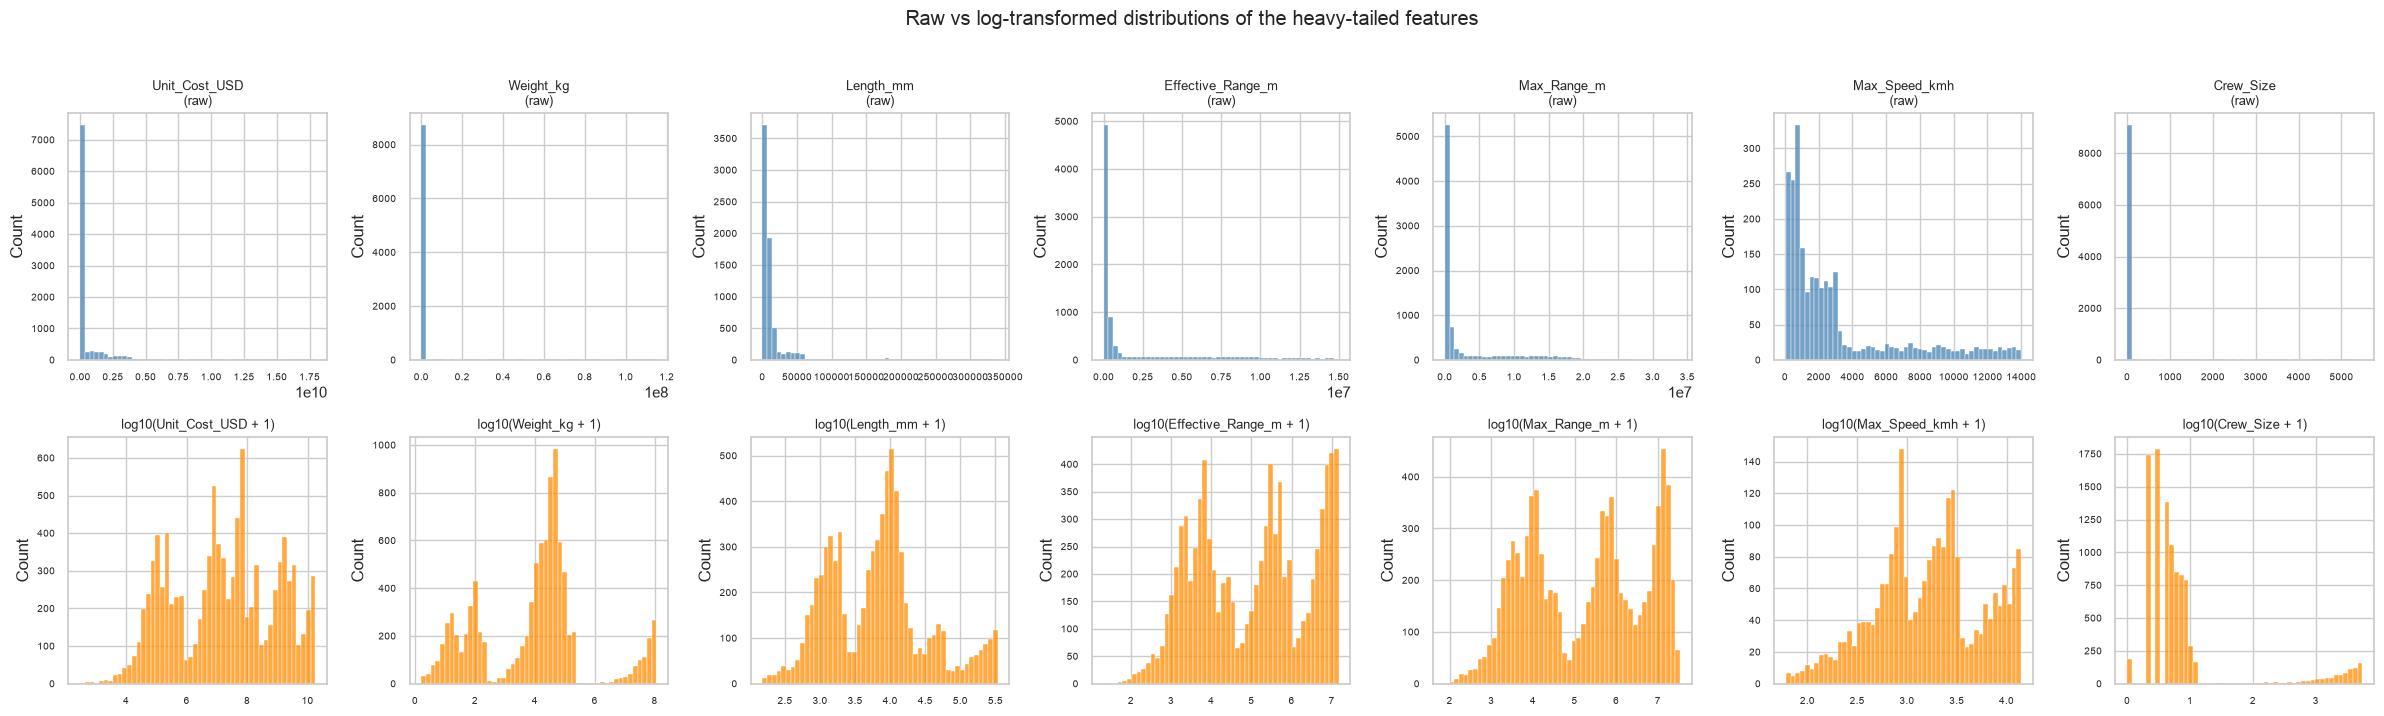

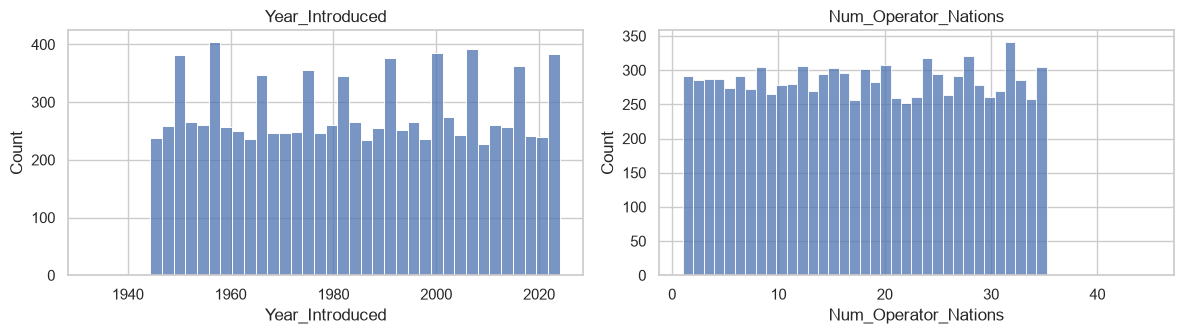

In [28]:
# Histograms: raw scale (top) vs log10 scale (bottom)
fig, axes = plt.subplots(2, 7, figsize=(24, 7))
for i, column in enumerate(LOG_FEATURES):
    values = weapons_df[column].dropna()
    sns.histplot(values, bins=50, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"{column}\n(raw)", fontsize=9)
    sns.histplot(np.log10(values + 1), bins=50, ax=axes[1, i], color="darkorange")
    axes[1, i].set_title(f"log10({column} + 1)", fontsize=9)
    for ax in axes[:, i]:
        ax.set_xlabel("")
        ax.tick_params(labelsize=7)
plt.suptitle("Raw vs log-transformed distributions of the heavy-tailed features", y=1.02)
plt.tight_layout()
plt.show()

# Year_Introduced and Num_Operator_Nations are not heavy-tailed - show them separately
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
sns.histplot(weapons_df["Year_Introduced"], bins=40, ax=axes[0])
sns.histplot(weapons_df["Num_Operator_Nations"], bins=45, ax=axes[1])
axes[0].set_title("Year_Introduced")
axes[1].set_title("Num_Operator_Nations")
plt.tight_layout()
plt.show()

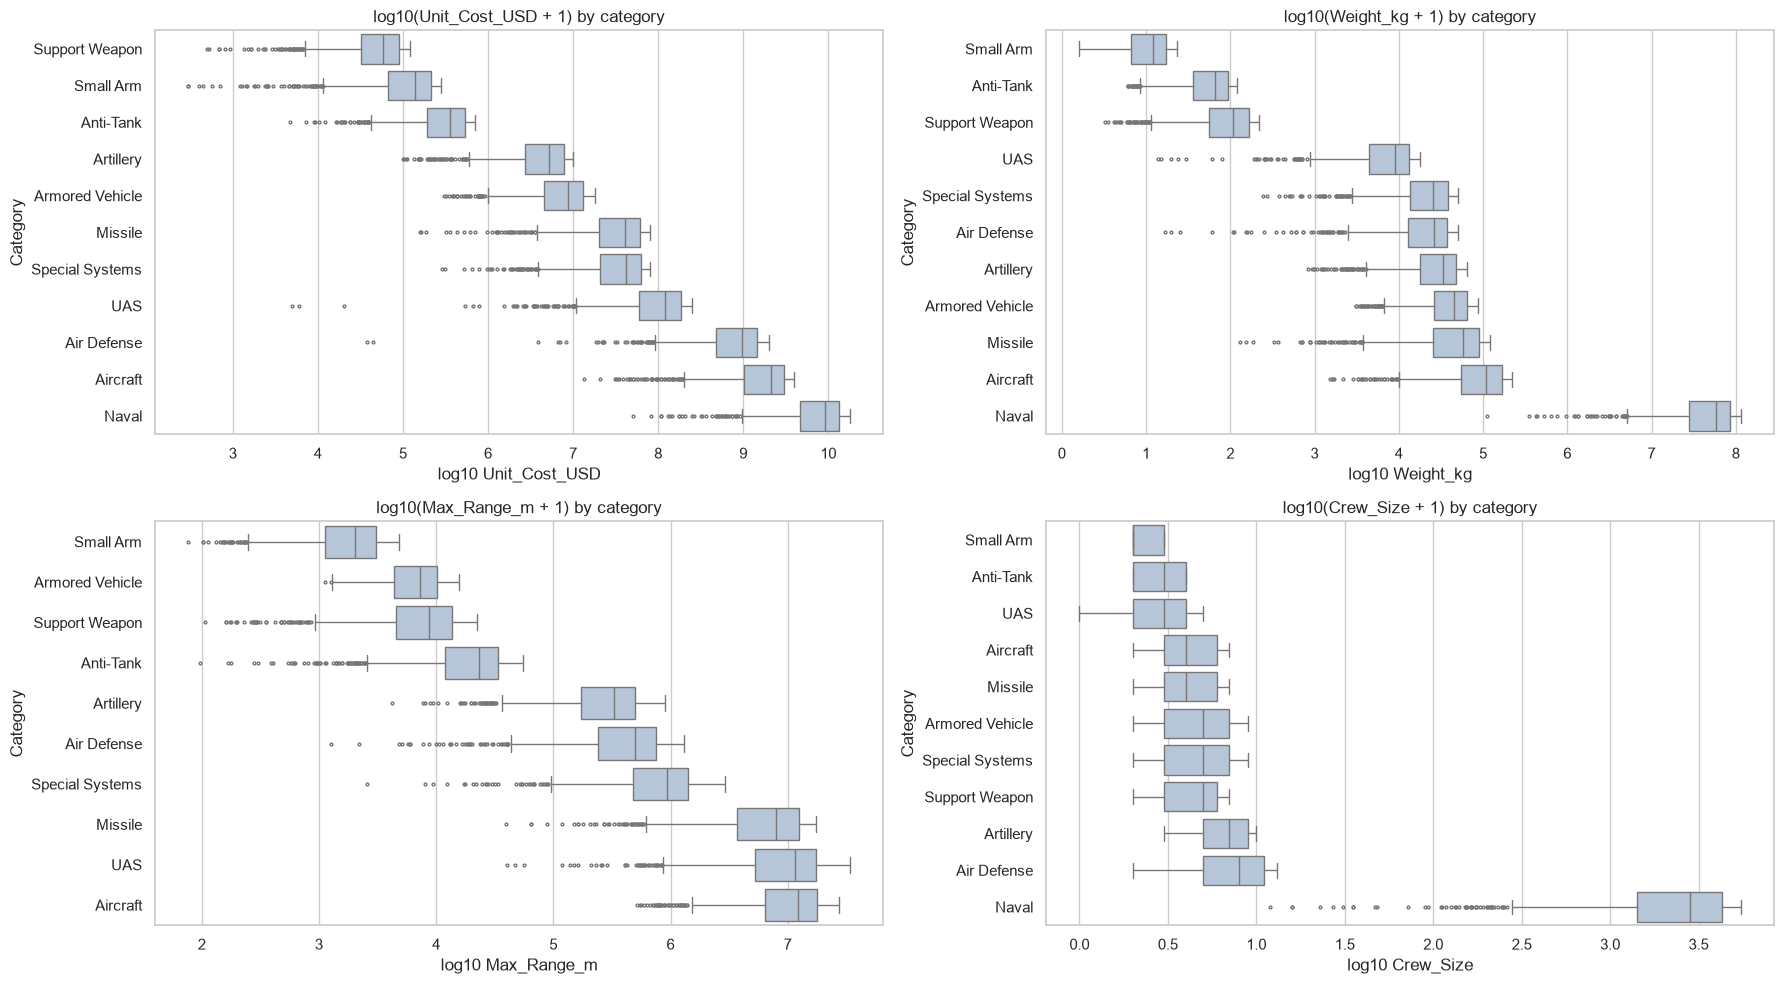

In [29]:
# Boxplots on the log scale, split by category, for the four most important features
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for ax, column in zip(axes.ravel(), ["Unit_Cost_USD", "Weight_kg", "Max_Range_m", "Crew_Size"]):
    plot_frame = weapons_df[["Category", column]].dropna()
    plot_frame[f"log10 {column}"] = np.log10(plot_frame[column] + 1)
    order = plot_frame.groupby("Category")[f"log10 {column}"].median().sort_values().index
    sns.boxplot(data=plot_frame, x=f"log10 {column}", y="Category", order=order, ax=ax,
                fliersize=2, color="lightsteelblue")
    ax.set_title(f"log10({column} + 1) by category")
plt.tight_layout()
plt.show()

**Interpretation.**
- On the raw scale, cost, weight, length and crew have skewness between 3.4 and 4.0 and large positive kurtosis. The mean is many times larger than the median, because a few hundred ships and aircraft dominate the totals. Cost and weight span **7 to 8 orders of magnitude**.
- After a `log10(x + 1)` transform, skewness falls close to zero for most features. The log histograms are **multi-modal**, not Gaussian: each mode is a family of weapons (portable weapons around 10 kg, vehicles around 30-50 tonnes, ships around 50,000 tonnes).
- `Crew_Size` stays skewed even after the log because it is bimodal: almost all systems have 0-12 crew, while naval vessels have 100-5,485.
- `Year_Introduced` (1950-2024) and `Num_Operator_Nations` (1-45) are almost perfectly **uniform**. Uniform distributions have negative excess kurtosis (about -1.2) and, as shown next, no correlation with anything else - typical of randomly generated fields.
- The category boxplots show that most of the variance of the physical features is **between categories**, not within them. This predicts that PCA and clustering will mostly rediscover the weapon families.

### 2.4 Correlation matrix

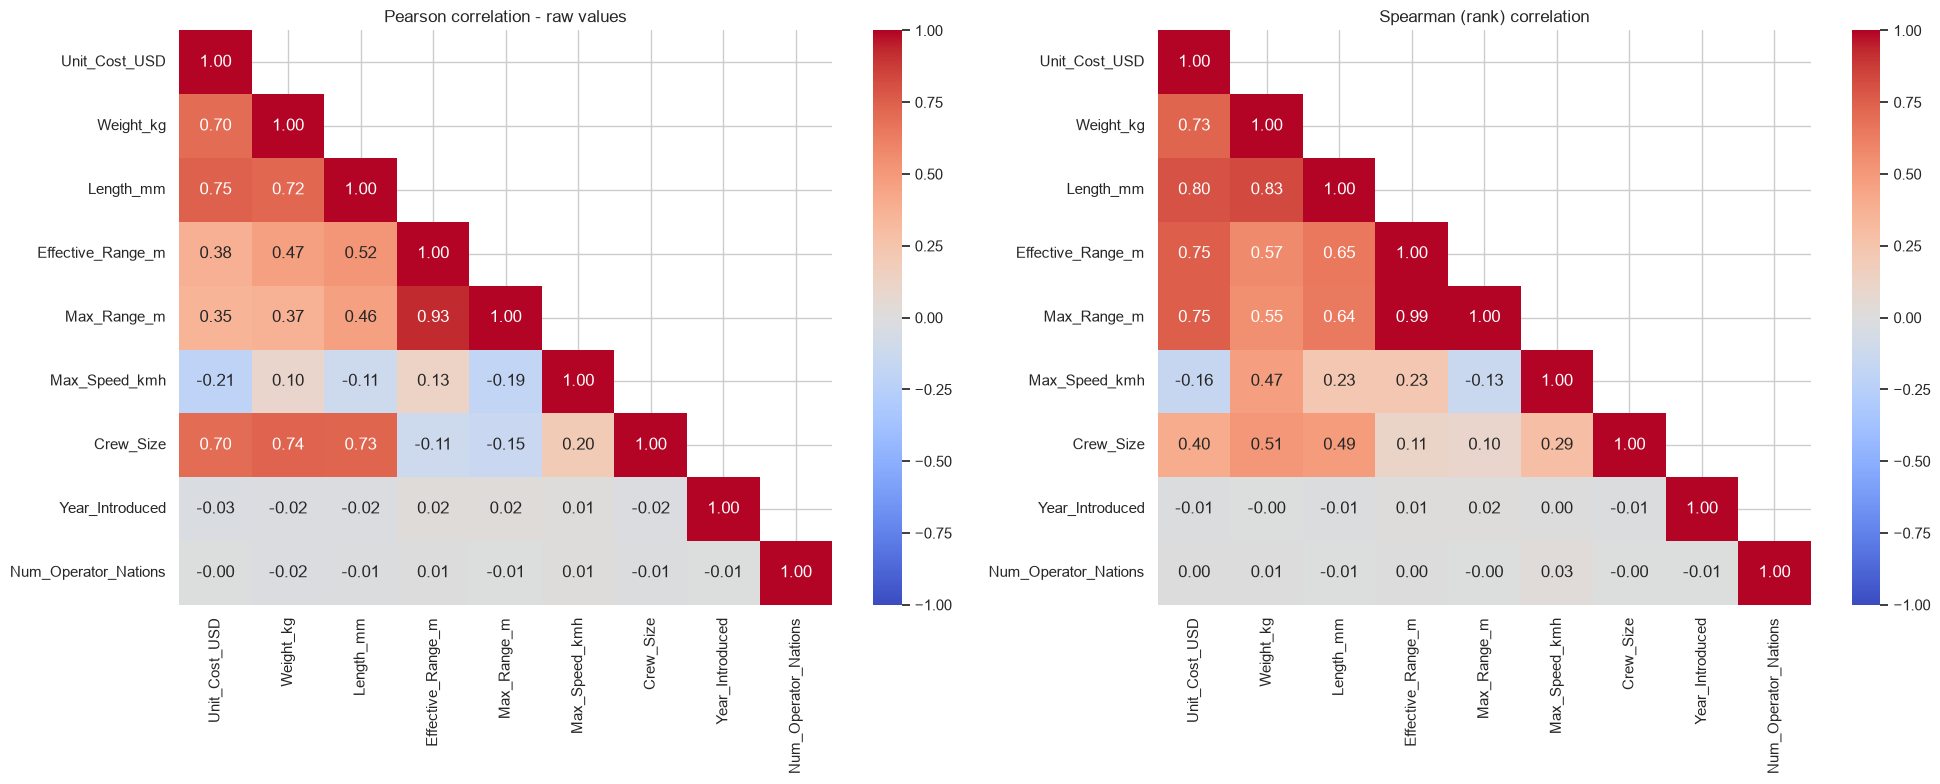

In [30]:
# Spearman (rank) correlation on raw values - robust to the heavy tails and to monotonic transforms
spearman_corr = weapons_df[CORE_FEATURES].corr(method="spearman")

# Pearson on the raw scale for comparison - dominated by extreme values
pearson_raw_corr = weapons_df[CORE_FEATURES].corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)
sns.heatmap(pearson_raw_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson correlation - raw values")
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman (rank) correlation")
plt.tight_layout()
plt.show()

**Interpretation.**
- **A strong "size / cost" block:** cost, weight, length, crew and the two range features are strongly correlated in rank. Bigger systems are more expensive, carry more crew, and (except ships, whose range is missing) reach further.
- **Effective range vs max range** are almost perfectly correlated in rank - they are redundant; one of them is almost a scaled copy of the other.
- **Year_Introduced and Num_Operator_Nations are uncorrelated with everything** (|r| close to 0). In real life newer systems are usually more expensive, and cheap systems are usually exported to more countries - the absence of these relationships is another sign of synthetic generation.
- The raw Pearson matrix differs from the Spearman matrix because a few naval rows (weight around 10^8 kg, crew in the thousands) dominate the sums of squares. This is why PCA below is applied to log-transformed, standardized data.

### 2.5 Outlier exploration - heavy tails, extreme values and artifacts

In [31]:
# One-dimensional IQR outliers on the raw scale vs log scale
def iqr_outlier_count(series):
    values = series.dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).sum())

outlier_table = pd.DataFrame({
    "IQR outliers (raw)": weapons_df[CORE_FEATURES].apply(iqr_outlier_count),
    "IQR outliers (log10)": weapons_df[CORE_FEATURES].apply(
        lambda s: iqr_outlier_count(np.log10(s + 1)) if s.name in LOG_FEATURES else iqr_outlier_count(s)
    ),
    "max value": weapons_df[CORE_FEATURES].max(),
    "99th percentile": weapons_df[CORE_FEATURES].quantile(0.99),
})
display(outlier_table)

print("Most expensive systems:")
display(weapons_df.nlargest(5, "Unit_Cost_USD")[["ID", "Weapon_Name", "Category", "Subcategory", "Unit_Cost_USD", "Weight_kg", "Crew_Size"]])

,IQR outliers (raw),IQR outliers (log10),max value,99th percentile
Unit_Cost_USD,2024,0,1.793200e+10,1.605897e+10
Weight_kg,1210,0,1.149785e+08,1.036748e+08
Length_mm,1156,43,3.392750e+05,3.059822e+05
Effective_Range_m,1505,0,1.499962e+07,1.424065e+07
Max_Range_m,1535,0,3.393791e+07,2.527434e+07
Max_Speed_kmh,376,7,1.399000e+04,1.358348e+04
Crew_Size,924,921,5.485000e+03,4.950000e+03
Year_Introduced,0,0,2.024000e+03,2.024000e+03
Num_Operator_Nations,0,0,4.500000e+01,3.500000e+01


Most expensive systems:


,ID,Weapon_Name,Category,Subcategory,Unit_Cost_USD,Weight_kg,Crew_Size
3442,3443,JS-207,Naval,Corvette,1.793200e+10,7.480844e+07,3137
1231,1232,MV-323,Naval,Guided Missile Destroyer,1.793065e+10,3.595471e+07,1017
7998,7999,FS-134,Naval,Guided Missile Cruiser,1.785986e+10,6.908667e+07,1937
3118,3119,USS-332,Naval,Fast Attack Craft,1.785787e+10,1.078242e+08,331
610,611,PN-468,Naval,Supercarrier,1.785422e+10,2.096993e+07,3715


In [32]:
# Detect template-generated rows from the structure of the Notes field
TEMPLATE_PATTERN = r"generation .*; operated by .*; .* service; .* optimised"
weapons_df["is_template_row"] = weapons_df["Notes"].str.contains(TEMPLATE_PATTERN, regex=True, na=False)
weapons_df["record_source"] = np.where(weapons_df["is_template_row"], "template-generated", "curated (real)")

print(weapons_df["record_source"].value_counts())
print("ID range of curated rows:", weapons_df.loc[~weapons_df["is_template_row"], "ID"].agg(["min", "max"]).tolist())

# Compare typical values of the same category in the two groups
comparison = (
    weapons_df[weapons_df["Category"].isin(["Small Arm", "Aircraft", "Missile", "Air Defense"])]
    .groupby(["Category", "record_source"])[["Unit_Cost_USD", "Weight_kg", "Max_Range_m", "Crew_Size"]]
    .median()
)
display(comparison.round(0))
display(weapons_df.loc[[0, 62, 64, 69, 72], ["ID", "Weapon_Name", "Category", "Unit_Cost_USD", "Weight_kg", "Crew_Size", "Notes"]])

record_source
template-generated    9937
curated (real)          63
Name: count, dtype: int64
ID range of curated rows: [1, 63]


Unit_Cost_USD  Weight_kg  Max_Range_m  Crew_Size
Category    record_source                                                       
Air Defense curated (real)       5.000000e+07       17.0      70000.0        4.0
            template-generated   9.568083e+08    25973.0     494291.0        7.0
Aircraft    curated (real)       9.000000e+07    24000.0    2980000.0        1.0
            template-generated   2.117119e+09   109430.0   12220321.0        3.0
Missile     curated (real)       2.750000e+06     1590.0     680000.0        1.0
            template-generated   4.060235e+07    58083.0    8022202.0        3.0
Small Arm   curated (real)       2.500000e+03        4.0       1000.0        1.0
            template-generated   1.413750e+05       11.0       2057.0        1.0

,ID,Weapon_Name,Category,Unit_Cost_USD,Weight_kg,Crew_Size,Notes
0,1,M4A1 Carbine,Small Arm,1.200000e+03,2.88,1,"Standard US military carbine; over 500,000 in ..."
62,63,F-16C Fighting Falcon,Aircraft,3.500000e+07,19200.00,1,Most produced Western fighter; 4600+ built; F-...
64,65,L-Flanker,Small Arm,2.116670e+05,10.37,1,3rd generation Pistol; operated by Vietnam; ac...
69,70,ROKS-308,Naval,4.443183e+09,7890062.42,4670,5th generation Offshore Patrol Vessel; operate...
72,73,USS-422,Naval,1.591616e+10,24221995.79,4590,3.5th generation Frigate; operated by Myanmar;...


The raw-scale IQR rule flags 1,000-2,000 "outliers" in each of cost, weight, length and range; after the log transform almost all of them disappear. The exception is `Crew_Size` (921 log-scale outliers), which is exactly the naval crew mode. This shows that an outlier on the raw scale is often just **a different kind of weapon** (a ship among rifles), not an error.

While inspecting individual rows I found a much more important pattern in the `Notes` column: almost every row follows the template *"&lt;generation&gt; generation &lt;subcategory&gt;; operated by &lt;country&gt;; &lt;status&gt; service; &lt;environment&gt; optimised"*. The cell below separates template rows from free-text rows and compares their values.

**Interpretation - a measurement artifact at dataset level.**

- Only **63 rows (IDs 1-63)** are curated descriptions of real systems (M4A1 Carbine, F-16C, Leopard 1A5, Shahed-136...). Their values match public knowledge: an M4A1 costs about \$1,200 and an F-16C about \$35 million.
- The other **9,937 rows are template-generated**. Their names are generic codes (`AK-498`, `USS-422`), and their values are often implausible: the median template "Small Arm" costs about \$140,000 (about 50 times a real rifle), template aircraft have a median *effective* range of about 7,900 km, and an "Offshore Patrol Vessel operated by Estonia" has a crew of 4,670 and is "Mountain optimised".

This finding changes the meaning of every result below:
1. The "normal" majority of the data is the synthetic distribution. **Real systems are the minority, so they may look anomalous** - an anomaly detector learns what is *common*, not what is *correct*.
2. Because no anomaly labels exist, I will use `record_source` as a **proxy label** in Section 6 - not as ground truth, but as a sanity check of which method notices a group of records that was produced by a different process.
3. The extreme values of the template rows (ships with 5,000 crew) are *artifacts of the generator*, but inside this file they are perfectly "normal" for their category.

The column `record_source` is **never used as a model input** - only for interpretation.

## 3. Dimensionality Reduction - PCA

### Assignment requirements addressed
- Preprocessing (imputation, transformation, scaling)
- Explained variance ratio, cumulative explained variance, Scree plot
- 2D and 3D projections
- Number of components, information loss, correlated variables, interpretation of components
- Local vs global structure, stability, redundancy

### 3.1 Mathematical intuition

Let $X \in \mathbb{R}^{n \times p}$ be the centered and standardized data matrix. PCA finds orthonormal directions $w_1, w_2, \dots$ that maximize the projected variance:

$$w_1 = \arg\max_{\|w\|=1} \operatorname{Var}(Xw) = \arg\max_{\|w\|=1} w^\top \Sigma w, \qquad \Sigma = \tfrac{1}{n-1}X^\top X$$

The solution is the eigen-decomposition $\Sigma = W \Lambda W^\top$. Each eigenvalue $\lambda_j$ is the variance captured by component $j$, and the explained variance ratio is $\lambda_j / \sum_k \lambda_k$. Equivalently, PCA gives the best rank-$k$ linear approximation of $X$ in squared (Frobenius) error.

Because PCA is based on **variance and linear correlation**, it is sensitive to scale and to extreme values. That is why the preprocessing below is essential.

### 3.2 Preprocessing
1. **Feature selection:** the nine core numerical features (Section 2.2).
2. **Log transform:** `log10(x + 1)` for the seven heavy-tailed features, so that one ship does not dominate the covariance matrix.
3. **Imputation:** median inside the same `Category`; global median when the entire category lacks the feature.
4. **Standardization:** `StandardScaler`, so every feature has mean 0 and variance 1. Without it, features measured in large units would dominate purely because of their unit.

Categorical columns are not one-hot encoded for PCA. With 11 categories and 141 subcategories, the binary columns would dominate the variance and PCA would simply reproduce the category labels. Instead, `Category` is kept aside and used to *evaluate* the unsupervised structure.

In [33]:
def build_feature_matrix(frame, features=CORE_FEATURES, log_features=LOG_FEATURES):
    # Log-transform heavy tails, then impute with category median (global median as fallback)
    matrix = frame[features].copy()
    for column in log_features:
        if column in matrix:
            matrix[column] = np.log10(matrix[column] + 1)
    for column in features:
        category_median = matrix.groupby(frame["Category"])[column].transform("median")
        matrix[column] = matrix[column].fillna(category_median).fillna(matrix[column].median())
    return matrix

features_log = build_feature_matrix(weapons_df)
scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features_log), columns=CORE_FEATURES, index=weapons_df.index)

print("Remaining missing values:", int(features_scaled.isna().sum().sum()))
display(features_scaled.describe().T[["mean", "std", "min", "max"]].round(2))

Remaining missing values: 0


,mean,std,min,max
Unit_Cost_USD,0.0,1.0,-2.80,1.79
Weight_kg,-0.0,1.0,-2.07,2.30
Length_mm,-0.0,1.0,-2.29,2.58
Effective_Range_m,0.0,1.0,-2.82,1.59
Max_Range_m,-0.0,1.0,-2.54,1.69
Max_Speed_kmh,-0.0,1.0,-1.96,2.01
Crew_Size,-0.0,1.0,-1.04,3.48
Year_Introduced,0.0,1.0,-2.22,1.71
Num_Operator_Nations,0.0,1.0,-1.68,2.65


,eigenvalue,explained_ratio,cumulative
PC1,4.008,0.445,0.445
PC2,1.510,0.168,0.613
PC3,1.007,0.112,0.725
PC4,0.991,0.110,0.835
PC5,0.976,0.108,0.944
PC6,0.257,0.029,0.972
PC7,0.160,0.018,0.990
PC8,0.088,0.010,1.000
PC9,0.004,0.000,1.000


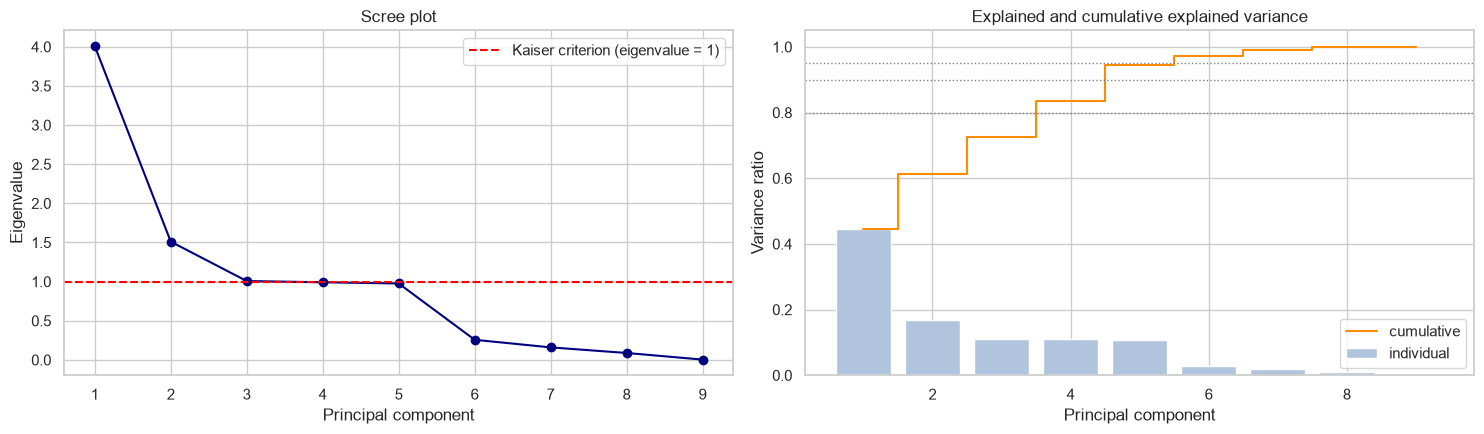

Components needed for 80% of the variance: 4
Components needed for 90% of the variance: 5
Components needed for 95% of the variance: 6


In [34]:
# Fit PCA with all components
pca_full = PCA(random_state=RANDOM_STATE)
pca_scores = pca_full.fit_transform(features_scaled)

explained_variance = pd.DataFrame({
    "eigenvalue": pca_full.explained_variance_,
    "explained_ratio": pca_full.explained_variance_ratio_,
    "cumulative": np.cumsum(pca_full.explained_variance_ratio_),
}, index=[f"PC{i+1}" for i in range(len(CORE_FEATURES))])
display(explained_variance.round(3))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].plot(range(1, 10), pca_full.explained_variance_, "o-", color="navy")
ax[0].axhline(1.0, color="red", linestyle="--", label="Kaiser criterion (eigenvalue = 1)")
ax[0].set_title("Scree plot")
ax[0].set_xlabel("Principal component")
ax[0].set_ylabel("Eigenvalue")
ax[0].legend()

ax[1].bar(range(1, 10), pca_full.explained_variance_ratio_, color="lightsteelblue", label="individual")
ax[1].step(range(1, 10), np.cumsum(pca_full.explained_variance_ratio_), where="mid", color="darkorange", label="cumulative")
for threshold in (0.8, 0.9, 0.95):
    ax[1].axhline(threshold, color="grey", linestyle=":", linewidth=1)
ax[1].set_title("Explained and cumulative explained variance")
ax[1].set_xlabel("Principal component")
ax[1].set_ylabel("Variance ratio")
ax[1].legend()
plt.tight_layout()
plt.show()

for threshold in (0.8, 0.9, 0.95):
    n_needed = int(np.argmax(explained_variance["cumulative"].values >= threshold) + 1)
    print(f"Components needed for {threshold:.0%} of the variance: {n_needed}")

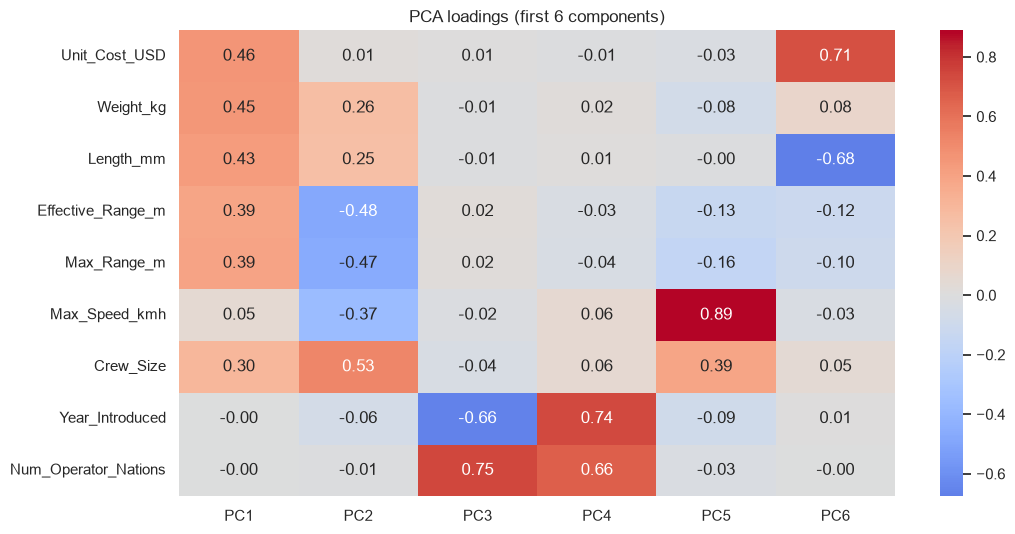

In [35]:
# Loadings: contribution of each original feature to each component
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=CORE_FEATURES,
    columns=[f"PC{i+1}" for i in range(len(CORE_FEATURES))],
)
plt.figure(figsize=(11, 5.5))
sns.heatmap(loadings.iloc[:, :6], annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("PCA loadings (first 6 components)")
plt.tight_layout()
plt.show()

**Interpretation - how many components and how much information is lost?**

- **PC1 explains about 44.5%** of the variance and is the only component far above the Kaiser line. It has almost equal positive loadings on cost, weight, length, both ranges and crew. It is a **"size / capability / cost" axis**: small arms on one side, ships and aircraft on the other.
- **PC2 (about 17%)** contrasts **range and speed** (negative loadings) with **crew, weight and length** (positive loadings). It separates things that *fly far and fast* (missiles, aircraft, UAS) from things that are *heavy and crewed* (ships, armoured vehicles).
- **PC3, PC4 and PC5 each explain about 11%** - almost exactly $1/9 \approx 11.1\%$, the share of a single standardized variable that is uncorrelated with the others. PC3 is dominated by `Year_Introduced` and `Num_Operator_Nations`, and PC4/PC5 are mixtures of them with the residual of speed. These components carry **noise, not structure**: their eigenvalues are close to 1 because the underlying variables are independent and uniform.
- **PC6-PC9 together explain less than 6%**. PC9 has an eigenvalue of essentially zero because `Effective_Range_m` and `Max_Range_m` are nearly collinear (redundancy).

So:
- **2 components keep about 61%** of the variance and almost all of the *structured* variance (size and range).
- **5 components are needed for 90%** - but only because 3 of those 5 components are spent on describing independent noise variables.
- The ~39% lost in a 2D view is mostly year and number of operators, which do not help separate weapon types in this file.

**Effect of correlated variables.** Five of the nine features form one correlated block, so PCA compresses them into PC1. Correlated features "vote together" - the size block gets five votes while the year gets one. If I had added more size-like columns (for example `Barrel_Length_mm`), PC1 would become even stronger simply because of redundancy, not because size is more important.

### 3.3 2D and 3D projections

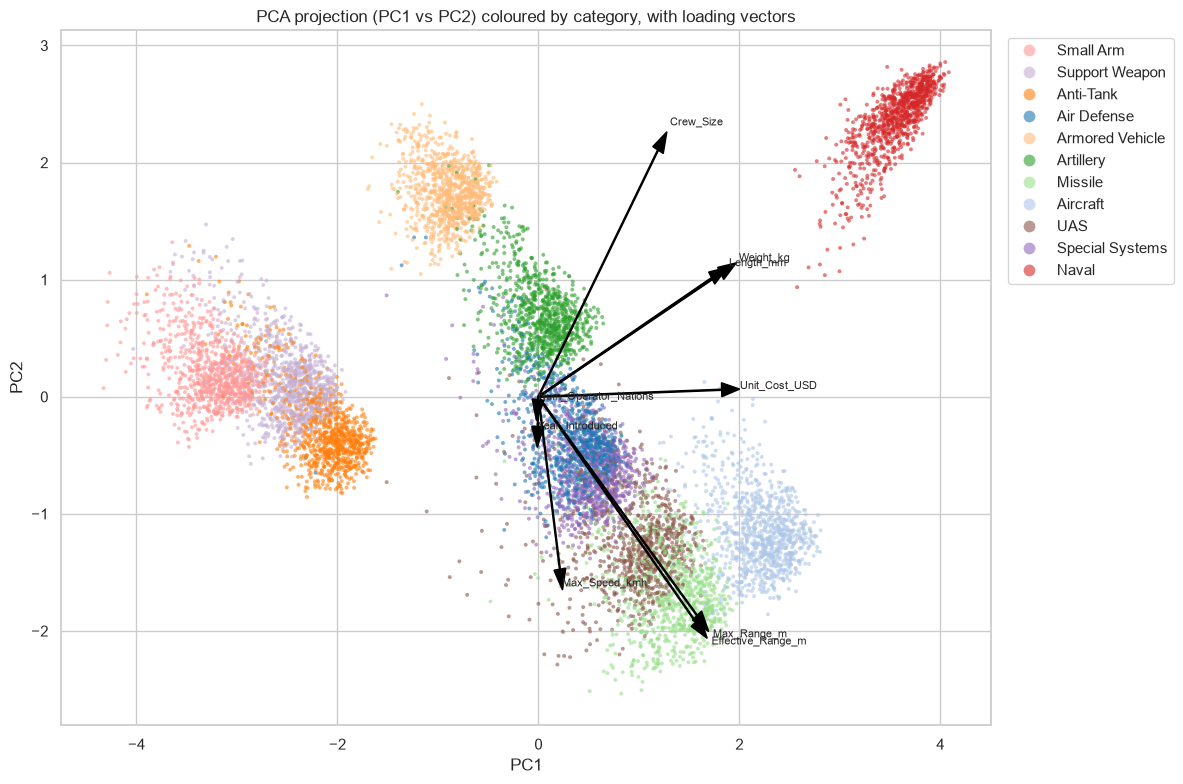

In [36]:
pca_2d = pd.DataFrame(pca_scores[:, :2], columns=["PC1", "PC2"], index=weapons_df.index)
pca_2d["Category"] = weapons_df["Category"]

palette = dict(zip(sorted(weapons_df["Category"].unique()), sns.color_palette("tab20", 11)))

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=pca_2d, x="PC1", y="PC2", hue="Category", palette=palette, s=8, alpha=0.6, ax=ax, linewidth=0)

# Draw loading vectors (biplot)
arrow_scale = 4
for feature in CORE_FEATURES:
    x, y = loadings.loc[feature, "PC1"] * arrow_scale, loadings.loc[feature, "PC2"] * arrow_scale
    ax.arrow(0, 0, x, y, color="black", width=0.01, head_width=0.12)
    ax.text(x * 1.1, y * 1.1, feature, fontsize=8)
ax.set_title("PCA projection (PC1 vs PC2) coloured by category, with loading vectors")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", markerscale=3)
plt.tight_layout()
plt.show()

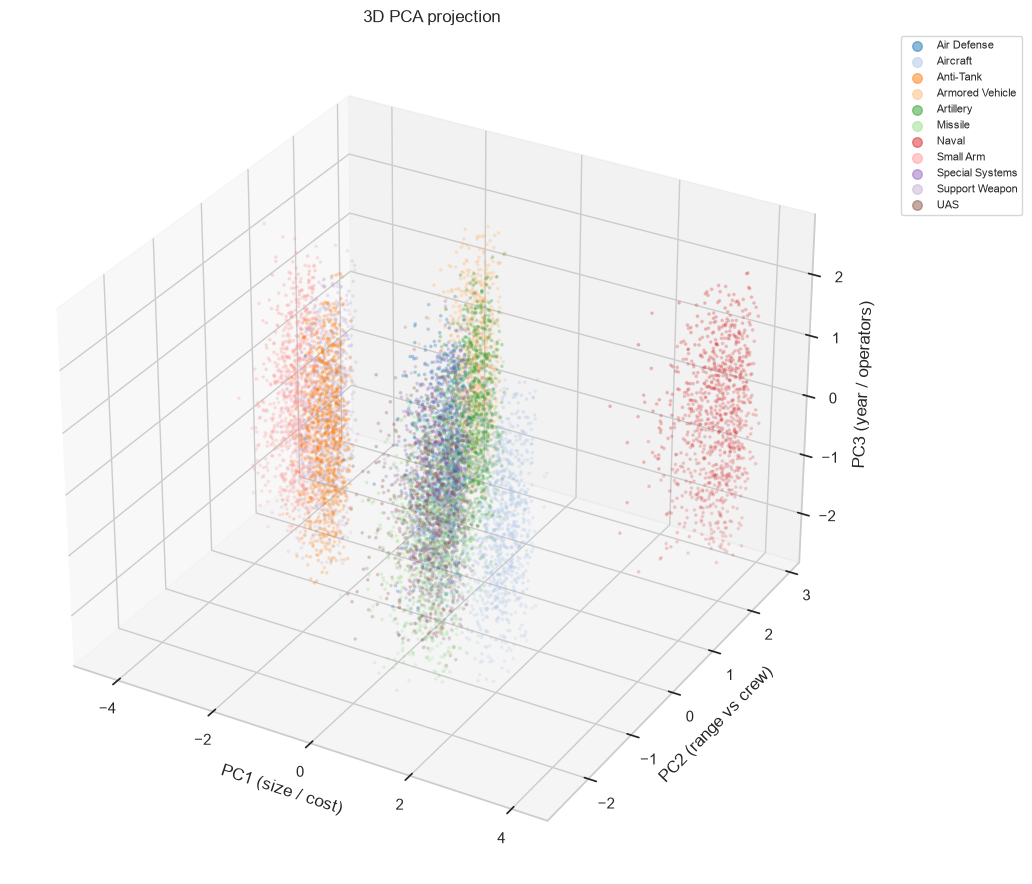

In [37]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")
for category, color in palette.items():
    mask = weapons_df["Category"] == category
    ax.scatter(pca_scores[mask, 0], pca_scores[mask, 1], pca_scores[mask, 2], s=3, alpha=0.5, color=color, label=category)
ax.set_xlabel("PC1 (size / cost)")
ax.set_ylabel("PC2 (range vs crew)")
ax.set_zlabel("PC3 (year / operators)")
ax.set_title("3D PCA projection")
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1), markerscale=4, fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation.**
- In 2D the categories form clearly separated "islands": portable weapons (Small Arm, Anti-Tank, Support Weapon) on the left of PC1, ground vehicles and artillery in the middle, a large aerospace group (Aircraft, Missile, Air Defense, UAS, Special Systems) with negative PC2 (long range), and Naval systems isolated at the top right (heavy, huge crew).
- The loading arrows confirm the interpretation: the two range arrows point together (redundancy), and the size arrows point to the right.
- The 3D plot adds PC3, which spreads every group vertically **without separating anything** - it is the direction of year and operator count, which are independent noise.
- Part of the separation is created by the preprocessing: ship range and rifle speed were imputed with a single constant value, so all ships share the same range value. This produces artificially thin structures. A real dataset would look much messier.

### 3.4 Stability, local vs global structure and sensitivity

In [38]:
# (a) Bootstrap stability of the first two components
bootstrap_loadings = {"PC1": [], "PC2": []}
reference = pca_full.components_[:2]
rng = np.random.default_rng(RANDOM_STATE)
for _ in range(30):
    sample_index = rng.choice(len(features_scaled), size=len(features_scaled), replace=True)
    boot_pca = PCA(n_components=2).fit(features_scaled.values[sample_index])
    for j, name in enumerate(["PC1", "PC2"]):
        component = boot_pca.components_[j]
        component = component * np.sign(component @ reference[j])  # fix sign ambiguity
        bootstrap_loadings[name].append(component)

stability = pd.DataFrame({
    "PC1 mean": np.mean(bootstrap_loadings["PC1"], axis=0),
    "PC1 std": np.std(bootstrap_loadings["PC1"], axis=0),
    "PC2 mean": np.mean(bootstrap_loadings["PC2"], axis=0),
    "PC2 std": np.std(bootstrap_loadings["PC2"], axis=0),
}, index=CORE_FEATURES).round(3)
display(stability)

# (b) Sensitivity: PCA without the heavily imputed Max_Speed_kmh and without the log transform
pca_no_speed = PCA().fit(StandardScaler().fit_transform(features_log.drop(columns="Max_Speed_kmh")))
raw_imputed = weapons_df[CORE_FEATURES].fillna(weapons_df[CORE_FEATURES].median())
pca_no_log = PCA().fit(StandardScaler().fit_transform(raw_imputed))
sensitivity = pd.DataFrame({
    "baseline (log + scaled)": pca_full.explained_variance_ratio_[:4],
    "without Max_Speed_kmh": pca_no_speed.explained_variance_ratio_[:4],
    "without log transform": pca_no_log.explained_variance_ratio_[:4],
}, index=["PC1", "PC2", "PC3", "PC4"]).round(3)
display(sensitivity)

# (c) Local structure: trustworthiness of the 2D and 3D embeddings (1 = neighbourhoods preserved)
sample_index = rng.choice(len(features_scaled), size=2000, replace=False)
sample_high_dim = features_scaled.values[sample_index]
for n_dims in (2, 3, 5):
    tw = trustworthiness(sample_high_dim, pca_scores[sample_index, :n_dims], n_neighbors=10)
    print(f"Trustworthiness of {n_dims}D PCA embedding (k=10): {tw:.3f}")

,PC1 mean,PC1 std,PC2 mean,PC2 std
Unit_Cost_USD,0.456,0.002,0.015,0.010
Weight_kg,0.453,0.004,0.263,0.010
Length_mm,0.431,0.004,0.253,0.007
Effective_Range_m,0.391,0.008,-0.480,0.009
Max_Range_m,0.395,0.008,-0.466,0.009
Max_Speed_kmh,0.054,0.005,-0.370,0.021
Crew_Size,0.298,0.011,0.525,0.008
Year_Introduced,-0.002,0.006,-0.063,0.024
Num_Operator_Nations,-0.001,0.006,-0.006,0.023


,baseline (log + scaled),without Max_Speed_kmh,without log transform
PC1,0.445,0.500,0.344
PC2,0.168,0.179,0.218
PC3,0.112,0.126,0.112
PC4,0.110,0.124,0.110


Trustworthiness of 2D PCA embedding (k=10): 0.884
Trustworthiness of 3D PCA embedding (k=10): 0.934
Trustworthiness of 5D PCA embedding (k=10): 0.996


**Interpretation.**
- **Stability:** over 30 bootstrap samples the loadings of PC1 and PC2 change only in the third decimal. The global directions are very stable - which is expected with 10,000 rows and a strong correlation block.
- **Sensitivity:** removing the 75%-imputed `Max_Speed_kmh` makes PC1 *stronger* (50% instead of 44.5%) because speed was not part of the size axis anyway - so the main axis is not an imputation artifact. Without the log transform PC1 drops to about 34%, because a few extreme values dominate the raw covariance and linear correlations weaken. The log transform is therefore a modelling decision with a real effect, not a cosmetic one.
- **Global vs local structure:** PCA is a *global* linear method - it preserves large distances (between weapon families) well. The trustworthiness score measures whether the nearest neighbours in the embedding are also neighbours in the original 9D space. It is 0.88 in 2D, 0.93 in 3D and 0.996 in 5D: inside each "island", the 2D view mixes up neighbours because the within-family differences (year, operators, small size variations) live in the discarded components. **Distances between islands can be trusted; distances inside an island cannot.**
- **Redundancy:** `Effective_Range_m` and `Max_Range_m` carry almost the same information (near-zero last eigenvalue); cost, weight and length are strongly redundant as well. The data are effectively about 2-dimensional in structure plus several independent noise dimensions.

## 4. Clustering Analysis

### Assignment requirements addressed
- Exactly three methods: K-Means, DBSCAN, Hierarchical Clustering
- Clustering of samples **and** of the feature space (transposed matrix)
- Mathematical intuition, assumptions, strengths and weaknesses
- Evaluation: average within-cluster variance vs global variance
- Visualization on the 2D PCA projection
- Hyperparameter sensitivity, density vs centroid approaches, where clustering fails

All sample clustering is done on the **full 9-dimensional standardized matrix**, not on the PCA scores. PCA is used only for visualization, so the clustering is not affected by the information lost in 2D.

### 4.1 Evaluation metric - within-cluster variance vs global variance

For a partition into clusters $C_1, \dots, C_K$ the metric used is

$$\text{Variance ratio} = \frac{\sum_{k} \frac{|C_k|}{n}\,\operatorname{tr}(\Sigma_{C_k})}{\operatorname{tr}(\Sigma_{\text{global}})}$$

which is the size-weighted average total variance inside the clusters divided by the total variance of the data. A value close to 0 means tight, homogeneous clusters; a value of 1 means the clustering explains nothing. I also report the silhouette score and the Adjusted Rand Index (ARI) against `Category` (used only for interpretation, never for fitting).

In [39]:
def within_cluster_variance_ratio(data, labels, ignore_noise=True):
    # Size-weighted mean within-cluster total variance divided by global total variance
    data = np.asarray(data)
    labels = np.asarray(labels)
    global_variance = data.var(axis=0).sum()
    valid = labels != -1 if ignore_noise else np.ones(len(labels), dtype=bool)
    weighted = 0.0
    for label in np.unique(labels[valid]):
        members = data[labels == label]
        weighted += len(members) / valid.sum() * members.var(axis=0).sum()
    return weighted / global_variance

def per_cluster_variance_table(data, labels):
    data = np.asarray(data)
    global_variance = data.var(axis=0).sum()
    rows = []
    for label in np.unique(labels):
        members = data[labels == label]
        rows.append({"cluster": label, "size": len(members),
                     "total variance": members.var(axis=0).sum(),
                     "variance / global": members.var(axis=0).sum() / global_variance})
    return pd.DataFrame(rows).set_index("cluster").round(3)

def evaluate_clustering(name, data, labels):
    labels = np.asarray(labels)
    valid = labels != -1
    n_clusters = len(np.unique(labels[valid]))
    silhouette = (silhouette_score(data[valid], labels[valid], sample_size=3000, random_state=RANDOM_STATE)
                  if n_clusters > 1 else np.nan)
    return {"method": name, "clusters": n_clusters, "noise points": int((~valid).sum()),
            "variance ratio": within_cluster_variance_ratio(data, labels),
            "silhouette": silhouette,
            "ARI vs Category": adjusted_rand_score(weapons_df["Category"][valid], labels[valid])}

X_samples = features_scaled.values
print("Global total variance (sum of feature variances):", round(X_samples.var(axis=0).sum(), 3))

Global total variance (sum of feature variances): 9.0


### 4.2 K-Means

**Intuition.** K-Means minimizes the within-cluster sum of squares

$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

by alternating two steps (Lloyd's algorithm): assign every point to its nearest centroid, then move every centroid to the mean of its points. Each step can only decrease $J$, so the algorithm converges - but to a local minimum, which is why several random initializations (`n_init`) are used.

**Assumptions:** clusters are convex, roughly spherical, of similar size and variance, and Euclidean distance is meaningful (so scaling matters). $K$ must be chosen in advance.

**Strengths:** fast ($O(nKp)$ per iteration), simple, scales to large data, centroids are interpretable "prototype weapons".  
**Weaknesses:** sensitive to scaling and outliers (the mean is not robust), cannot find elongated or nested clusters, forces every point into a cluster (no concept of noise).

,inertia,silhouette,variance ratio
K,,,
2,60350.503,0.306,0.671
3,44925.743,0.347,0.499
4,33380.844,0.387,0.371
5,30015.666,0.325,0.334
6,27904.143,0.264,0.310
7,25871.590,0.259,0.287
8,24315.766,0.262,0.270
9,22935.966,0.249,0.255
10,21671.355,0.241,0.241


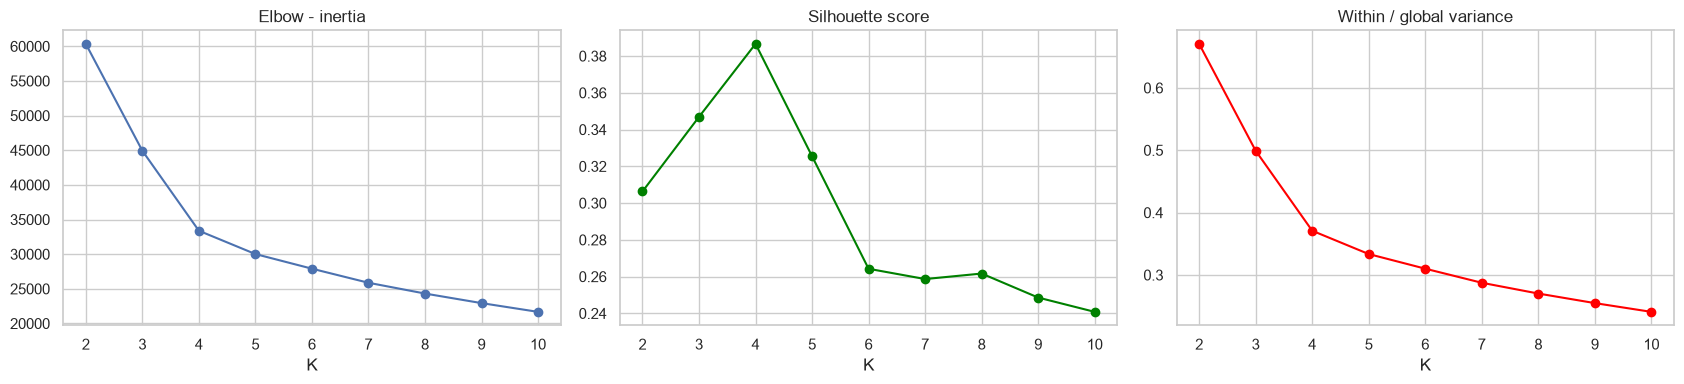

In [40]:
# Choose K using the elbow (inertia), silhouette and the variance ratio
k_values = range(2, 11)
k_search = []
for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_samples)
    k_search.append({
        "K": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_samples, model.labels_, sample_size=3000, random_state=RANDOM_STATE),
        "variance ratio": within_cluster_variance_ratio(X_samples, model.labels_),
    })
k_search = pd.DataFrame(k_search).set_index("K")
display(k_search.round(3))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(k_search.index, k_search["inertia"], "o-"); axes[0].set_title("Elbow - inertia")
axes[1].plot(k_search.index, k_search["silhouette"], "o-", color="green"); axes[1].set_title("Silhouette score")
axes[2].plot(k_search.index, k_search["variance ratio"], "o-", color="red"); axes[2].set_title("Within / global variance")
for ax in axes: ax.set_xlabel("K")
plt.tight_layout()
plt.show()

In [42]:
BEST_K = int(k_search["silhouette"].idxmax())
kmeans_model = KMeans(n_clusters=BEST_K, n_init=20, random_state=RANDOM_STATE).fit(X_samples)
weapons_df["kmeans_cluster"] = kmeans_model.labels_
print(f"Selected K = {BEST_K}")

display(pd.crosstab(weapons_df["Category"], weapons_df["kmeans_cluster"]))
display(per_cluster_variance_table(X_samples, kmeans_model.labels_))

# Centroids back in original units (median of members is more robust than the mean for readability)
centroid_profile = weapons_df.groupby("kmeans_cluster")[CORE_FEATURES].median()
display(comparison.round(0))

Selected K = 4


kmeans_cluster,0,1,2,3
Category,,,,
Air Defense,5,908,16,0
Aircraft,0,948,0,0
Anti-Tank,900,0,0,0
Armored Vehicle,0,0,929,0
Artillery,0,0,897,0
Missile,0,903,0,0
Naval,0,0,0,925
Small Arm,918,0,0,0
Special Systems,10,811,2,0


,size,total variance,variance / global
cluster,,,
0,2759,2.742,0.305
1,4457,3.979,0.442
2,1859,3.090,0.343
3,925,2.530,0.281


Unit_Cost_USD  Weight_kg  Max_Range_m  Crew_Size
Category    record_source                                                       
Air Defense curated (real)       5.000000e+07       17.0      70000.0        4.0
            template-generated   9.568083e+08    25973.0     494291.0        7.0
Aircraft    curated (real)       9.000000e+07    24000.0    2980000.0        1.0
            template-generated   2.117119e+09   109430.0   12220321.0        3.0
Missile     curated (real)       2.750000e+06     1590.0     680000.0        1.0
            template-generated   4.060235e+07    58083.0    8022202.0        3.0
Small Arm   curated (real)       2.500000e+03        4.0       1000.0        1.0
            template-generated   1.413750e+05       11.0       2057.0        1.0

**Interpretation.** The silhouette score peaks at **K = 4**, and the elbow bends at the same point. The four clusters have a very clear real-world meaning:

| Cluster | Categories | Real-world meaning |
|---|---|---|
| Portable / infantry weapons | Small Arm, Anti-Tank, Support Weapon | light, cheap, crewed by 1-4 soldiers, short range |
| Heavy ground systems | Armored Vehicle, Artillery | tens of tonnes, several million dollars, short to medium range |
| Aerospace and long-range | Aircraft, Missile, UAS, Air Defense, Special Systems | long range, fast, expensive |
| Naval | Naval | tens of thousands of tonnes, billions of dollars, crews in the thousands |

K-Means does **not** separate Aircraft from Missiles or Air Defense: in the numerical feature space these families overlap strongly. The per-cluster variance table shows that each cluster keeps a large part of the global variance - the within-cluster variance is dominated by the year and operator-count dimensions, which no cluster can explain.

### 4.3 DBSCAN

**Intuition.** DBSCAN defines clusters as dense regions. A point is a *core point* if at least `min_samples` points lie within distance `eps`. Clusters are the connected components of core points (plus border points reachable from them); all remaining points are labelled **noise (-1)**.

**Assumptions:** clusters are regions of similar, high density separated by low-density gaps; a single global `eps` is appropriate for all clusters.

**Strengths:** no need to choose $K$; finds arbitrarily shaped clusters; built-in notion of noise, which connects naturally to anomaly detection.  
**Weaknesses:** very sensitive to `eps`; struggles when clusters have different densities; in high dimensions distances concentrate and choosing `eps` becomes hard.

`min_samples` is set to $2p = 18$ (a common rule of thumb). `eps` is chosen from the k-distance plot: the distance to the 18th nearest neighbour, sorted - the "knee" separates dense regions from sparse points.

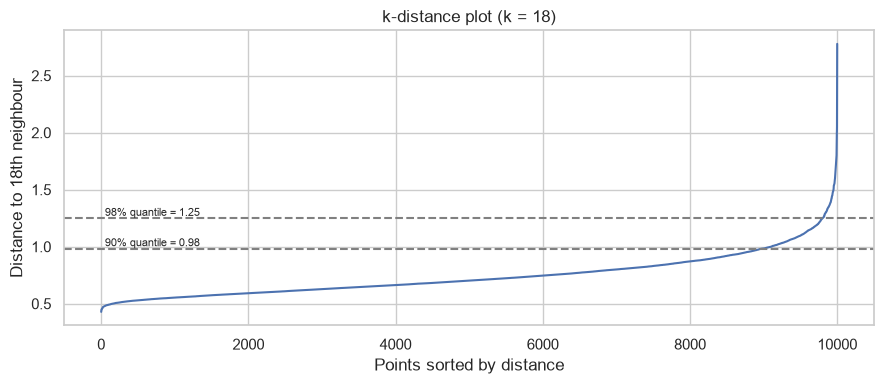

,clusters,noise points,variance ratio,silhouette,ARI vs Category
eps,,,,,
0.7,14,2034,0.253,0.266,0.675
0.8,5,883,0.319,0.337,0.510
0.9,4,370,0.360,0.396,0.361
1.0,4,147,0.366,0.396,0.354
1.1,3,71,0.509,0.354,0.193
1.2,3,39,0.510,0.357,0.193
1.5,2,6,0.772,0.382,0.040


In [43]:
MIN_SAMPLES = 2 * X_samples.shape[1]
neighbours = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_samples)
k_distances = np.sort(neighbours.kneighbors(X_samples)[0][:, -1])

plt.figure(figsize=(9, 4))
plt.plot(k_distances)
for q in (0.90, 0.98):
    plt.axhline(np.quantile(k_distances, q), linestyle="--", color="grey")
    plt.text(50, np.quantile(k_distances, q) + 0.02, f"{q:.0%} quantile = {np.quantile(k_distances, q):.2f}", fontsize=8)
plt.title(f"k-distance plot (k = {MIN_SAMPLES})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {MIN_SAMPLES}th neighbour")
plt.tight_layout()
plt.show()

# Sensitivity of DBSCAN to eps
eps_search = []
for eps in [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5]:
    labels = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X_samples)
    eps_search.append({"eps": eps, **evaluate_clustering("DBSCAN", X_samples, labels)})
display(pd.DataFrame(eps_search).drop(columns="method").set_index("eps").round(3))

In [44]:
DBSCAN_EPS = 1.0
dbscan_labels = DBSCAN(eps=DBSCAN_EPS, min_samples=MIN_SAMPLES).fit_predict(X_samples)
weapons_df["dbscan_cluster"] = dbscan_labels
display(pd.crosstab(weapons_df["Category"], weapons_df["dbscan_cluster"]))
print("Noise points by record source:")
display(pd.crosstab(weapons_df["record_source"], weapons_df["dbscan_cluster"] == -1))

dbscan_cluster,-1,0,1,2,3
Category,,,,,
Air Defense,9,0,0,920,0
Aircraft,1,0,0,947,0
Anti-Tank,1,899,0,0,0
Armored Vehicle,0,0,929,0,0
Artillery,0,0,897,0,0
Missile,38,0,0,865,0
Naval,17,0,0,0,908
Small Arm,3,915,0,0,0
Special Systems,12,0,0,811,0


Noise points by record source:


dbscan_cluster,False,True
record_source,,
curated (real),47,16
template-generated,9806,131


**Interpretation.**
- The k-distance curve is flat for most points and rises sharply only in the last few percent - the knee is around 1.0. With `eps = 1.0` DBSCAN finds **4 clusters and 147 noise points**, and the clusters match the K-Means families.
- **Sensitivity is extreme:** `eps = 0.7` breaks the data into 14 clusters and labels about 2,000 points (20%) as noise; `eps = 1.5` merges almost everything into two clusters with only 6 noise points. The "right" answer depends entirely on a hyperparameter that has no physical meaning.
- The noise points are concentrated in UAS, Missile and Naval systems - categories whose values are more spread. **16 of the 63 curated real records (25%) are labelled noise, compared with 1.3% of the template rows**, because the real systems lie outside the dense synthetic clouds.
- **Density vs centroid:** K-Means must assign every weapon to a centroid, even an extreme one; DBSCAN can refuse. On the other hand DBSCAN assumes one density for all groups, while here the Naval cluster is much more spread than the Small Arm cluster.

### 4.4 Hierarchical (agglomerative) clustering

**Intuition.** Start with every point as its own cluster, and repeatedly merge the two closest clusters. The *linkage* defines "closest": single (nearest points), complete (farthest points), average, or **Ward**, which merges the pair that increases the total within-cluster variance the least:

$$\Delta(A,B) = \frac{|A||B|}{|A|+|B|}\,\|\mu_A - \mu_B\|^2$$

The full merge history is a **dendrogram**; cutting it at a given height gives a flat clustering.

**Assumptions:** depends on linkage - Ward assumes compact, variance-based clusters (similar to K-Means); single linkage assumes chained, connected clusters.

**Strengths:** no need to fix $K$ in advance, the dendrogram shows structure at all scales, deterministic.  
**Weaknesses:** $O(n^2)$ memory and at least $O(n^2)$ time, merges can never be undone (greedy), sensitive to the choice of linkage.

Ward clustering of 10,000 rows took 1.3 s


hierarchical_cluster,0,1,2,3
Category,,,,
Air Defense,927,2,0,0
Aircraft,948,0,0,0
Anti-Tank,0,900,0,0
Armored Vehicle,0,0,0,929
Artillery,0,0,0,897
Missile,903,0,0,0
Naval,0,0,925,0
Small Arm,0,918,0,0
Special Systems,823,0,0,0


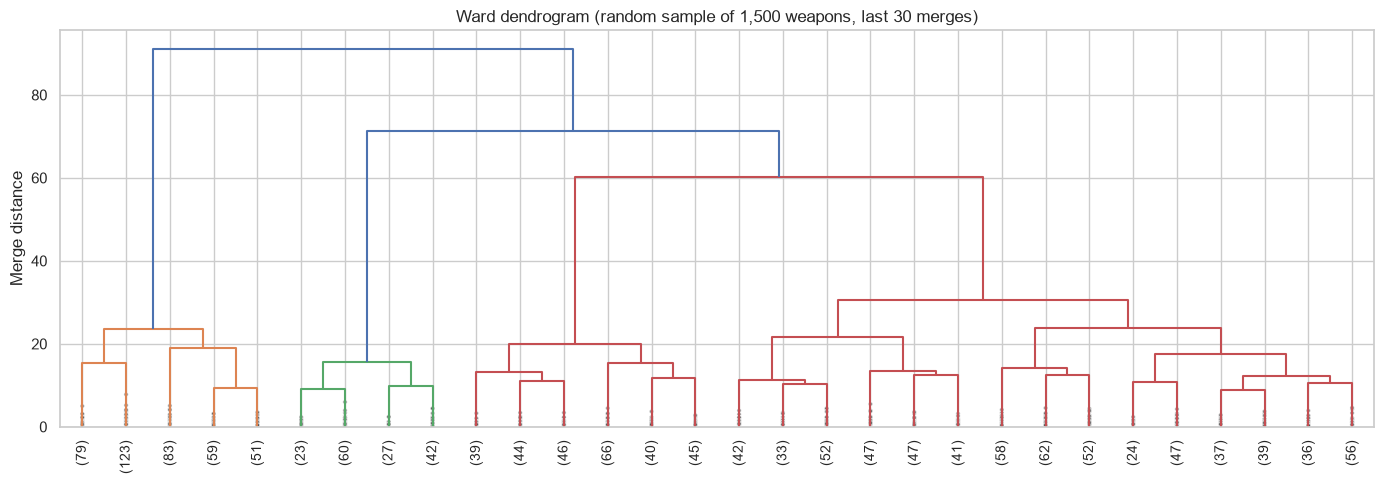

,ARI vs Ward (full data),variance ratio,largest cluster share
linkage,,,
ward,0.996,0.375,0.455
complete,0.682,0.413,0.325
average,0.982,0.375,0.450
single,0.173,0.775,0.907


In [45]:
# Ward clustering on the full dataset
start = time.perf_counter()
hierarchical_model = AgglomerativeClustering(n_clusters=BEST_K, linkage="ward").fit(X_samples)
print(f"Ward clustering of {len(X_samples):,} rows took {time.perf_counter() - start:.1f} s")
weapons_df["hierarchical_cluster"] = hierarchical_model.labels_
display(pd.crosstab(weapons_df["Category"], weapons_df["hierarchical_cluster"]))

# Dendrogram on a random sample (a 10,000-leaf dendrogram is unreadable)
dendro_index = np.random.default_rng(RANDOM_STATE).choice(len(X_samples), size=1500, replace=False)
ward_linkage = linkage(X_samples[dendro_index], method="ward")
plt.figure(figsize=(14, 5))
dendrogram(ward_linkage, truncate_mode="lastp", p=30, leaf_rotation=90, show_contracted=True)
plt.title("Ward dendrogram (random sample of 1,500 weapons, last 30 merges)")
plt.ylabel("Merge distance")
plt.tight_layout()
plt.show()

# Sensitivity to linkage (on a 3,000-row sample for speed)
link_index = np.random.default_rng(RANDOM_STATE).choice(len(X_samples), size=3000, replace=False)
reference_labels = hierarchical_model.labels_[link_index]
linkage_rows = []
for method in ["ward", "complete", "average", "single"]:
    labels = AgglomerativeClustering(n_clusters=BEST_K, linkage=method).fit_predict(X_samples[link_index])
    linkage_rows.append({"linkage": method,
                         "ARI vs Ward (full data)": adjusted_rand_score(reference_labels, labels),
                         "variance ratio": within_cluster_variance_ratio(X_samples[link_index], labels),
                         "largest cluster share": np.bincount(labels).max() / len(labels)})
display(pd.DataFrame(linkage_rows).set_index("linkage").round(3))

**Interpretation.** Ward linkage reproduces the same four families as K-Means (this is expected - both minimize within-cluster variance). The dendrogram shows four long vertical branches before the last merges, i.e. four well-separated groups, followed by many short merges inside each group (no meaningful sub-structure).

The linkage table shows how fragile hierarchical clustering is: **single linkage** suffers from the *chaining effect* - one giant cluster absorbs almost everything and the other "clusters" are a few isolated points. Average linkage is almost identical to Ward here (ARI 0.98), while complete linkage (ARI 0.68) splits the large aerospace group differently. The method is only as good as the definition of distance between groups.

### 4.5 Comparison of the three sample clusterings and visualization on PCA

,clusters,noise points,variance ratio,silhouette,ARI vs Category
method,,,,,
K-Means (K=4),4,0,0.371,0.387,0.349
DBSCAN (eps=1.0),4,147,0.366,0.396,0.354
Hierarchical Ward (K=4),4,0,0.372,0.387,0.350
Reference: true Category,11,0,0.276,0.181,1.000


Agreement between methods (ARI):
K-Means vs Hierarchical: 0.987
K-Means vs DBSCAN (non-noise): 0.993


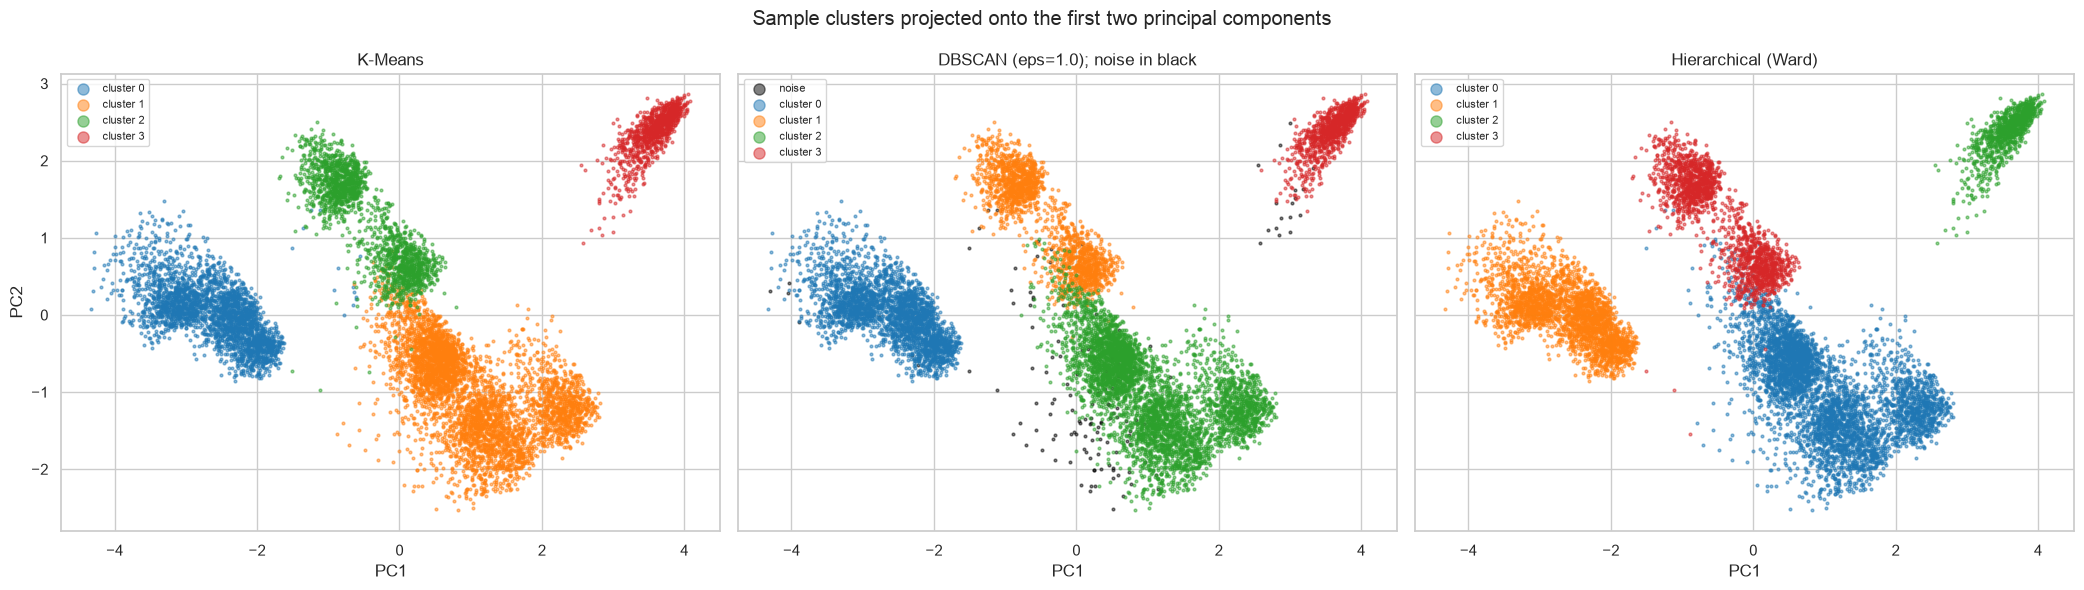

In [46]:
clustering_summary = pd.DataFrame([
    evaluate_clustering("K-Means (K=%d)" % BEST_K, X_samples, weapons_df["kmeans_cluster"]),
    evaluate_clustering("DBSCAN (eps=%.1f)" % DBSCAN_EPS, X_samples, weapons_df["dbscan_cluster"]),
    evaluate_clustering("Hierarchical Ward (K=%d)" % BEST_K, X_samples, weapons_df["hierarchical_cluster"]),
    evaluate_clustering("Reference: true Category", X_samples, weapons_df["Category"].astype("category").cat.codes),
]).set_index("method")
display(clustering_summary.round(3))

print("Agreement between methods (ARI):")
print("K-Means vs Hierarchical:", round(adjusted_rand_score(weapons_df["kmeans_cluster"], weapons_df["hierarchical_cluster"]), 3))
core_mask = weapons_df["dbscan_cluster"] != -1
print("K-Means vs DBSCAN (non-noise):", round(adjusted_rand_score(weapons_df.loc[core_mask, "kmeans_cluster"], weapons_df.loc[core_mask, "dbscan_cluster"]), 3))

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, sharey=True)
for ax, column, title in zip(
    axes,
    ["kmeans_cluster", "dbscan_cluster", "hierarchical_cluster"],
    ["K-Means", f"DBSCAN (eps={DBSCAN_EPS}); noise in black", "Hierarchical (Ward)"],
):
    labels = weapons_df[column]
    for label in sorted(labels.unique()):
        mask = labels == label
        ax.scatter(pca_scores[mask, 0], pca_scores[mask, 1], s=4, alpha=0.5,
                   color="black" if label == -1 else plt.cm.tab10(label % 10),
                   label="noise" if label == -1 else f"cluster {label}")
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.legend(markerscale=4, fontsize=8)
axes[0].set_ylabel("PC2")
plt.suptitle("Sample clusters projected onto the first two principal components")
plt.tight_layout()
plt.show()

**Interpretation.**
- All three methods reduce the size-weighted within-cluster variance to about **37% of the global variance** (individual clusters range from 28% to 44%). For comparison, even the true 11 categories leave 28%. The remaining variance is mainly year and number of operators (uniform noise) - no clustering of these features is possible because they have no clusters.
- K-Means and Ward agree almost perfectly (ARI = 0.99), and DBSCAN agrees with them on its non-noise points. Three methods with very different assumptions reaching the same partition is strong evidence that the four families are real structure *in this file*.
- The ARI against the true 11 categories is only about 0.35: the clusters are **coarser** than the categories. Categories that share physical characteristics (Aircraft / Missile / UAS / Air Defense) cannot be separated with these features alone.
- The 2D plot looks cleaner than the actual 9D clusters: in 2D the four islands look perfectly separated, but inside each island the points are spread along year and operator directions that the plot does not show.

**Where clustering fails in this dataset.**
1. **Within families** - the aerospace cluster mixes five categories.
2. **On the uniform features** - no method can find clusters in `Year_Introduced` or `Num_Operator_Nations`.
3. **Imputation artifacts** - the constant imputed ship range and rifle speed make clusters look more compact than the real data would be. Part of the "success" is created by the category-median imputation, which leaks the category into the features.
4. **Hyperparameters** - K for K-Means, eps for DBSCAN and linkage for hierarchical clustering each change the result dramatically. Without labels there is no objective way to choose them - only internal indices (silhouette, variance ratio) and domain sense.

### 4.6 Clustering the feature space (transposed data matrix)

Clustering the **transpose** $X^\top \in \mathbb{R}^{p \times n}$ treats each *feature* as a point in a 10,000-dimensional space whose coordinates are the values of that feature for every weapon. Two standardized features are close when they move together across weapons. For standardized columns the squared Euclidean distance is directly related to correlation:

$$\|x_a - x_b\|^2 = 2(n-1)(1 - r_{ab})$$

so clustering features is effectively clustering the correlation matrix. To treat strong negative correlation as redundancy as well, the hierarchical and DBSCAN versions use the distance $d_{ab} = 1 - |r_{ab}|$.

The same three methods are applied:

Transposed matrix shape: (9, 10000)


,K-Means (K=3),Hierarchical (cut at 1-|r| = 0.5),DBSCAN (eps=0.5)
Effective_Range_m,1,1,0
Max_Range_m,1,1,0
Unit_Cost_USD,0,2,0
Weight_kg,0,2,0
Length_mm,0,2,0
Crew_Size,0,2,0
Max_Speed_kmh,2,3,-1
Year_Introduced,2,4,-1
Num_Operator_Nations,2,5,-1


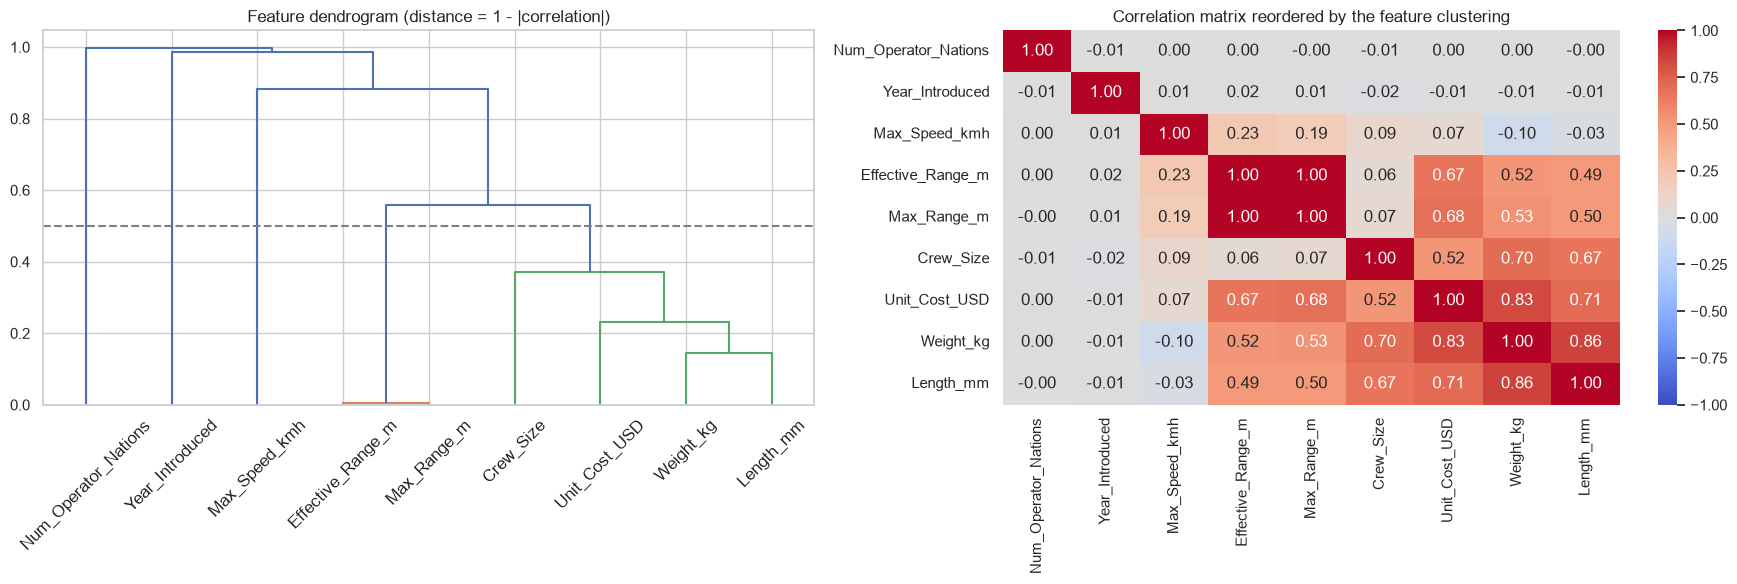

In [47]:
X_features = features_scaled.values.T          # shape: 9 features x 10,000 weapons
print("Transposed matrix shape:", X_features.shape)

feature_corr = features_scaled.corr()
feature_distance = 1 - feature_corr.abs()

# (1) K-Means on the rows of the transposed matrix
kmeans_features = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE).fit(X_features)

# (2) Hierarchical clustering with average linkage on 1 - |r|
condensed = squareform(feature_distance.values, checks=False)
feature_linkage = linkage(condensed, method="average")
hierarchical_features = fcluster(feature_linkage, t=0.5, criterion="distance")

# (3) DBSCAN on the precomputed 1 - |r| distance
dbscan_features = DBSCAN(eps=0.5, min_samples=2, metric="precomputed").fit_predict(feature_distance.values)

feature_clusters = pd.DataFrame({
    "K-Means (K=3)": kmeans_features.labels_,
    "Hierarchical (cut at 1-|r| = 0.5)": hierarchical_features,
    "DBSCAN (eps=0.5)": dbscan_features,
}, index=CORE_FEATURES)
display(feature_clusters.sort_values("Hierarchical (cut at 1-|r| = 0.5)"))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
dendrogram(feature_linkage, labels=CORE_FEATURES, leaf_rotation=45, ax=axes[0], color_threshold=0.5)
axes[0].axhline(0.5, linestyle="--", color="grey")
axes[0].set_title("Feature dendrogram (distance = 1 - |correlation|)")
order = dendrogram(feature_linkage, no_plot=True, labels=CORE_FEATURES)["ivl"]
sns.heatmap(feature_corr.loc[order, order], annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlation matrix reordered by the feature clustering")
plt.tight_layout()
plt.show()

**Interpretation - groups of related / redundant features.**
- **Range group:** `Effective_Range_m` and `Max_Range_m` merge first (almost identical). This is a pure redundancy: max range is roughly a multiple of effective range.
- **Size / cost group:** `Unit_Cost_USD`, `Weight_kg`, `Length_mm` and `Crew_Size` form one block - they all measure "how big is the platform".
- The range group joins the size group at a larger distance: range is correlated with size overall, but for different reasons (aircraft are big *and* far-reaching, ships are big but have no range recorded).
- **Singletons:** `Year_Introduced`, `Num_Operator_Nations` and `Max_Speed_kmh` stay isolated. Year and operators are independent of everything; speed is isolated partly because 75% of it is imputed.
- All three methods agree on these groups - DBSCAN labels the independent features as noise, which is a natural description of "a feature that belongs to no group".

**Why feature clustering is useful.**
1. **Redundancy removal / feature selection:** one representative per group (for example `Max_Range_m` and `Unit_Cost_USD`) would keep most information with fewer columns, reducing multicollinearity in regression models such as those in HW2.
2. **Understanding PCA:** each feature cluster corresponds to one principal component - the size group is PC1, the range-vs-size contrast is PC2, and each singleton gets its own ~11% component.
3. **Weighting:** correlated groups get multiple "votes" in distance-based methods (K-Means, LOF). Knowing the groups warns that the size of a weapon dominates every Euclidean distance in this notebook.
4. **Data quality:** a feature that is uncorrelated with all physically related features (like the year here) can indicate a random or corrupted field.

## 5. Multi-Dimensional Anomaly Detection

### Assignment requirements addressed
- Z-score (Gaussian assumption, high-dimensional failure, feature-wise vs global anomalies)
- Isolation Forest (isolation mechanism, random partitioning, contamination, scores, visualization)
- Local Outlier Factor (local density, neighbourhood effects, parameter k, global vs local anomalies, visualization)

There is no anomaly label, so the methods are compared with each other and with domain knowledge. All methods use the same standardized log-feature matrix as the clustering. To compare methods on equal terms, Isolation Forest and LOF use a contamination of **2% (200 weapons)**.

In [48]:
CONTAMINATION = 0.02
N_FLAGGED = int(CONTAMINATION * len(weapons_df))
DISPLAY_COLUMNS = ["ID", "Weapon_Name", "Category", "Subcategory", "record_source",
                   "Unit_Cost_USD", "Weight_kg", "Max_Range_m", "Crew_Size", "Year_Introduced"]

def plot_anomalies_on_pca(flags, scores, title):
    # Left: flagged points on the PCA plane. Right: continuous anomaly score.
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)
    axes[0].scatter(pca_scores[~flags, 0], pca_scores[~flags, 1], s=3, color="lightgrey", label="normal")
    axes[0].scatter(pca_scores[flags, 0], pca_scores[flags, 1], s=14, color="red", label=f"anomaly (n={flags.sum()})")
    axes[0].set_title(f"{title} - flagged points")
    axes[0].legend()
    order = np.argsort(scores)
    points = axes[1].scatter(pca_scores[order, 0], pca_scores[order, 1], c=scores[order], s=4, cmap="viridis")
    plt.colorbar(points, ax=axes[1], label="anomaly score (higher = more anomalous)")
    axes[1].set_title(f"{title} - continuous score")
    for ax in axes:
        ax.set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    plt.tight_layout()
    plt.show()

runtimes = {}

### 5.1 Z-score method

**Mechanism.** For each feature $j$: $z_{ij} = (x_{ij} - \bar{x}_j)/s_j$. A value is anomalous if $|z_{ij}| > 3$. Under a Gaussian distribution only 0.27% of values exceed this threshold.

Two ways to go from features to a multi-dimensional decision:
- **Feature-wise ("any") rule:** a weapon is anomalous if *any* of its 9 features has $|z| > 3$. This finds extreme values in a single dimension.
- **Global (aggregate) rule:** $D_i^2 = \sum_j z_{ij}^2$. If the features were independent standard Gaussians, $D^2 \sim \chi^2_9$, so the threshold is the 99.73% quantile of $\chi^2_9$. This finds weapons that are moderately unusual in *many* features at once. (It is a Mahalanobis distance that ignores correlations.)

**Gaussian assumption.** The 3-sigma rule is only calibrated if the data are Gaussian. On heavy-tailed data the mean and the standard deviation are themselves inflated by the extremes (*masking*), and on multi-modal data "far from the mean" can simply mean "a different family".

,|z|>3 on log scale,|z|>3 on raw scale,expected if Gaussian
Unit_Cost_USD,0,403,27
Weight_kg,0,411,27
Length_mm,0,385,27
Effective_Range_m,0,299,27
Max_Range_m,0,245,27
Max_Speed_kmh,0,349,27
Crew_Size,563,422,27
Year_Introduced,0,0,27
Num_Operator_Nations,0,0,27


Feature-wise rule (any |z|>3, log scale): 563 weapons
Feature-wise rule on the raw scale:       1589 weapons
Global rule (sum z^2 > chi2_9 threshold 25.3): 205 weapons
Flagged weapons by category (feature-wise rule):


col_0,normal,anomaly
Category,,
Air Defense,929,0
Aircraft,948,0
Anti-Tank,900,0
Armored Vehicle,929,0
Artillery,897,0
Missile,903,0
Naval,362,563
Small Arm,918,0
Special Systems,823,0


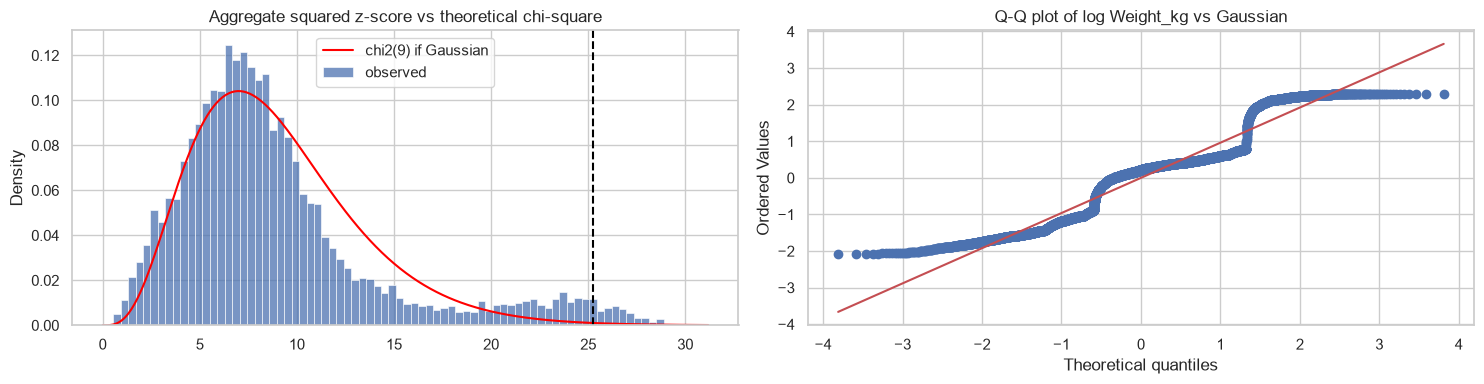

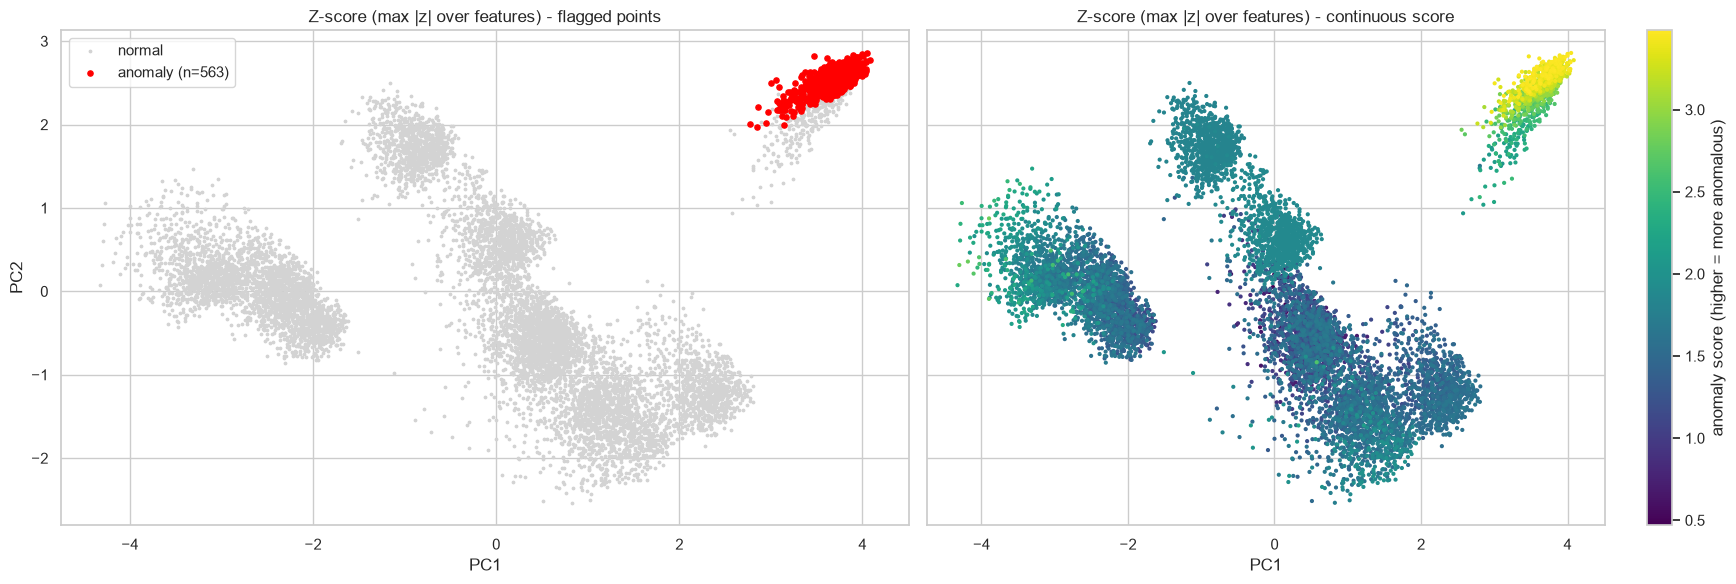

In [49]:
start = time.perf_counter()
z_matrix = features_scaled.values                    # already (x - mean) / std on the log scale
feature_wise_flags = np.abs(z_matrix) > 3
zscore_any_flags = feature_wise_flags.any(axis=1)

zscore_global_score = (z_matrix ** 2).sum(axis=1)
chi2_threshold = stats.chi2.ppf(0.9973, df=z_matrix.shape[1])
zscore_global_flags = zscore_global_score > chi2_threshold
runtimes["Z-score"] = time.perf_counter() - start

# The same rule on the RAW (not log-transformed) data, to show the effect of the Gaussian assumption
raw_values = weapons_df[CORE_FEATURES].fillna(weapons_df[CORE_FEATURES].median())
raw_z = (raw_values - raw_values.mean()) / raw_values.std()

zscore_table = pd.DataFrame({
    "|z|>3 on log scale": feature_wise_flags.sum(axis=0),
    "|z|>3 on raw scale": (raw_z.abs() > 3).sum().values,
    "expected if Gaussian": round(0.0027 * len(weapons_df)),
}, index=CORE_FEATURES)
display(zscore_table)

print(f"Feature-wise rule (any |z|>3, log scale): {zscore_any_flags.sum()} weapons")
print(f"Feature-wise rule on the raw scale:       {(raw_z.abs() > 3).any(axis=1).sum()} weapons")
print(f"Global rule (sum z^2 > chi2_9 threshold {chi2_threshold:.1f}): {zscore_global_flags.sum()} weapons")
print("Flagged weapons by category (feature-wise rule):")
display(pd.crosstab(weapons_df["Category"], zscore_any_flags).rename(columns={False: "normal", True: "anomaly"}))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(zscore_global_score, bins=80, ax=axes[0], stat="density", label="observed")
grid = np.linspace(0, zscore_global_score.max(), 400)
axes[0].plot(grid, stats.chi2.pdf(grid, df=9), color="red", label="chi2(9) if Gaussian")
axes[0].axvline(chi2_threshold, linestyle="--", color="black")
axes[0].set_title("Aggregate squared z-score vs theoretical chi-square")
axes[0].legend()
stats.probplot(features_scaled["Weight_kg"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot of log Weight_kg vs Gaussian")
plt.tight_layout()
plt.show()

plot_anomalies_on_pca(zscore_any_flags, np.abs(z_matrix).max(axis=1), "Z-score (max |z| over features)")

**Interpretation.**
- On the **log scale**, the feature-wise rule flags about 560 weapons - and **every single one is flagged because of `Crew_Size`**, and they are all Naval. After the log transform the other features have no values beyond 3 standard deviations: uniform and multi-modal distributions have *short* tails, so the 3-sigma rule finds nothing there.
- On the **raw scale** the rule flags 1,589 weapons - almost three times as many - driven by cost, weight, length, range and speed (each about 15 times the Gaussian expectation of 27). The result depends completely on a transformation choice - the Z-score does not measure "abnormality", it measures distance from the mean *in a chosen scale*.
- The global $\chi^2$ rule flags 205 weapons, a different set. The histogram shows that the observed $D^2$ distribution does not match $\chi^2_9$ at all, because the features are correlated (five of them are nearly one variable) and non-Gaussian. The threshold is therefore mis-calibrated in both directions.
- **Feature-wise vs global anomalies:** a weapon with ordinary values in every single feature but an impossible *combination* (for example a cheap, light system with an intercontinental range) is never found by the feature-wise rule. The Q-Q plot shows that log weight is far from Gaussian (multi-modal "steps").
- **High dimensions:** with $p$ independent Gaussian features, the probability that a *normal* point has at least one $|z|>3$ is $1-(0.9973)^p$ - about 2.4% for $p=9$ and about 24% for $p=100$. With many features, the feature-wise rule flags normal points just by chance (a multiple testing problem). In addition, the norm of a normal point grows like $\sqrt{p}$, so any fixed global threshold stops making sense.

### 5.2 Isolation Forest

**Mechanism.** Instead of modelling what is normal, Isolation Forest isolates points. Each tree is built on a random sub-sample; at each node it picks a **random feature** and a **random split value** between the minimum and maximum of that feature, and recurses until every point is alone. Anomalies are few and different, so they are separated by fewer random cuts - they have a **short average path length** $h(x)$ from the root.

The score is normalized by $c(n)$, the average path length of an unsuccessful search in a binary search tree:

$$s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}$$

$s \to 1$: very short paths (anomaly); $s \approx 0.5$ or below: normal. (scikit-learn's `score_samples` returns the negative of this; I flip it so that higher = more anomalous.)

**Contamination** does not change the trees or the scores - it only sets the decision threshold (the proportion of points labelled anomalous). Choosing it requires prior knowledge of how many anomalies exist, which we do not have.

**Why it works in high dimensions:** it never computes distances, works on random single-feature splits, uses sub-samples (256 points per tree), and scales linearly in $n$. Its weakness is that axis-parallel splits struggle with anomalies that exist only in a diagonal direction, and irrelevant features dilute the splits.

Flagged: 200 weapons, score threshold = 0.566


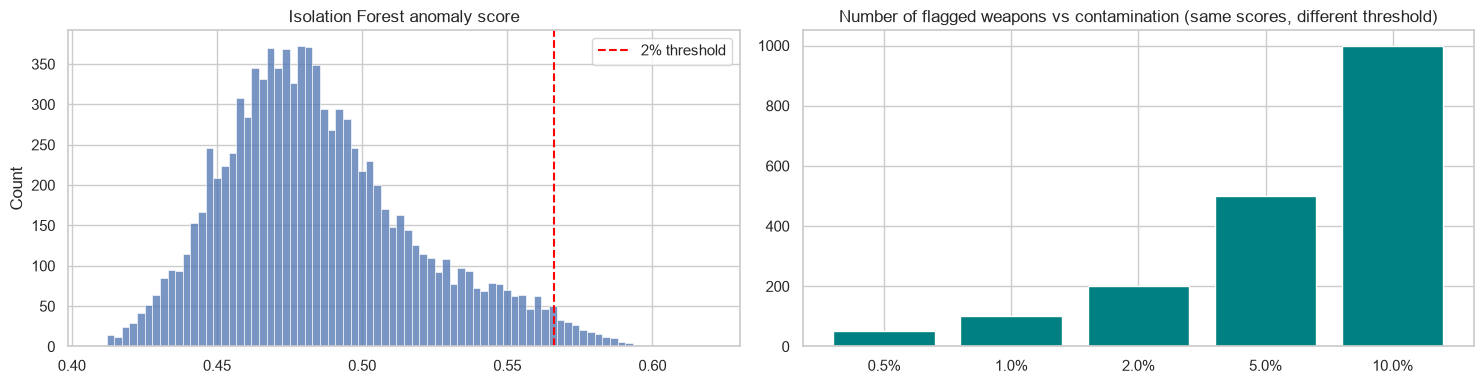

col_0,normal,anomaly
Category,,
Air Defense,929,0
Aircraft,948,0
Anti-Tank,900,0
Armored Vehicle,928,1
Artillery,897,0
Missile,903,0
Naval,752,173
Small Arm,897,21
Special Systems,823,0


Top 10 most anomalous weapons (Isolation Forest):


,ID,Weapon_Name,Category,Subcategory,record_source,Unit_Cost_USD,Weight_kg,Max_Range_m,Crew_Size,Year_Introduced,iforest_score
2124,2125,MSBS-Eagle,Small Arm,Personal Defence Weapon,template-generated,1.913500e+04,2.28,494.0,1,2024,0.619498
9413,9414,HMS-397,Naval,Mine Countermeasure,template-generated,1.772849e+10,4750617.18,NaN,5179,1950,0.607766
19,20,Switchblade 600,UAS,Loitering Munition,curated (real),6.000000e+03,22.90,40000.0,1,2021,0.602910
3681,3682,G-432,Small Arm,Personal Defence Weapon,template-generated,6.993000e+03,NaN,440.0,2,1953,0.599282
7636,7637,ACR-74,Small Arm,Grenade Launcher,template-generated,2.318710e+05,1.98,201.0,2,1950,0.598930
4571,4572,HMS-108,Naval,Fast Attack Craft,template-generated,5.727222e+09,5538339.39,NaN,5459,2024,0.597931
9180,9181,JS-36,Naval,Guided Missile Destroyer,template-generated,1.611806e+10,33253403.78,NaN,5272,1945,0.595103
835,836,INS-392,Naval,Fast Attack Craft,template-generated,1.749825e+10,62595119.91,NaN,5151,1950,0.593714
8033,8034,JS-195,Naval,Offshore Patrol Vessel,template-generated,3.310615e+08,99590851.27,NaN,5230,2014,0.592655
4098,4099,MCX-C1,Small Arm,Carbine,template-generated,1.413750e+05,15.21,157.0,1,2024,0.591727


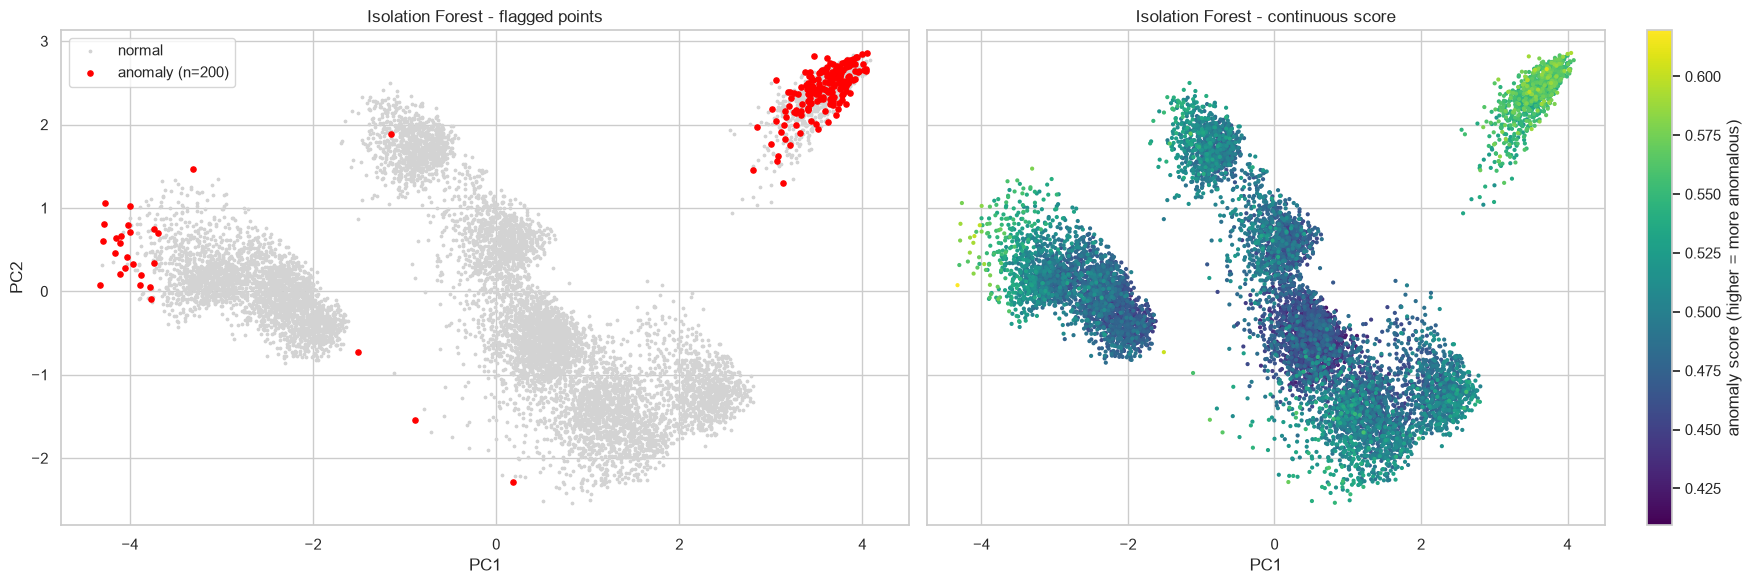

In [50]:
start = time.perf_counter()
isolation_forest = IsolationForest(n_estimators=300, max_samples=256, contamination=CONTAMINATION,
                                   random_state=RANDOM_STATE).fit(X_samples)
iforest_score = -isolation_forest.score_samples(X_samples)     # higher = more anomalous
iforest_flags = isolation_forest.predict(X_samples) == -1
runtimes["Isolation Forest"] = time.perf_counter() - start

print(f"Flagged: {iforest_flags.sum()} weapons, score threshold = {-isolation_forest.offset_:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(iforest_score, bins=80, ax=axes[0])
axes[0].axvline(-isolation_forest.offset_, color="red", linestyle="--", label="2% threshold")
axes[0].set_title("Isolation Forest anomaly score")
axes[0].legend()
contamination_grid = [0.005, 0.01, 0.02, 0.05, 0.10]
counts = [(iforest_score > np.quantile(iforest_score, 1 - c)).sum() for c in contamination_grid]
axes[1].bar([f"{c:.1%}" for c in contamination_grid], counts, color="teal")
axes[1].set_title("Number of flagged weapons vs contamination (same scores, different threshold)")
plt.tight_layout()
plt.show()

display(pd.crosstab(weapons_df["Category"], iforest_flags).rename(columns={False: "normal", True: "anomaly"}))
print("Top 10 most anomalous weapons (Isolation Forest):")
display(weapons_df.assign(iforest_score=iforest_score).nlargest(10, "iforest_score")[DISPLAY_COLUMNS + ["iforest_score"]])

plot_anomalies_on_pca(iforest_flags, iforest_score, "Isolation Forest")

**Interpretation.**
- The score distribution is continuous with a long right tail and **no natural gap** - the 2% threshold is an arbitrary cut. Changing contamination only moves the cut; the ranking stays the same.
- The flagged weapons are concentrated in **Naval** systems, plus a group of **Small Arms**. On the PCA plot the anomalies lie on the outer edge of the global cloud - the extreme right of PC1 (largest ships) and the extreme left (smallest, cheapest weapons). Isolation Forest is essentially a **global extremeness detector**: a point on the boundary of the data range is isolated by the first few random cuts.
- 6 of the 200 flagged weapons are curated real records (M4A1 Carbine, AK-12, XM5, RPG-7V2, Switchblade 600, Shahed-136). They are **correct** data - but they are far cheaper and lighter than the synthetic small arms. The model is right that they are *different*; it is not right if we interpret "anomaly" as "error".

### 5.3 Local Outlier Factor (LOF)

**Mechanism.** LOF compares the density around a point with the density around its neighbours.
1. $k$-distance of $x$: the distance to its $k$-th nearest neighbour.
2. Reachability distance: $\text{reach}_k(x, o) = \max\{k\text{-dist}(o), d(x, o)\}$ (smooths small distances).
3. Local reachability density: $\text{lrd}_k(x) = \left(\frac{1}{k}\sum_{o \in N_k(x)} \text{reach}_k(x, o)\right)^{-1}$.
4. $\text{LOF}_k(x) = \frac{1}{k}\sum_{o \in N_k(x)} \frac{\text{lrd}_k(o)}{\text{lrd}_k(x)}$.

$\text{LOF} \approx 1$: the point is as dense as its neighbours. $\text{LOF} \gg 1$: the point is in a sparser region than its neighbours - a **local** anomaly.

**Global vs local anomalies:** a point can be far from the global centre but inside a dense group (not a local anomaly, e.g. a typical ship), or close to the centre but in a sparse gap between two dense groups (a local anomaly). LOF is designed to detect the second kind. Its parameter $k$ defines the size of the neighbourhood: small $k$ finds tiny local irregularities (and noise), large $k$ becomes more global and more stable.

Flagged: 200 weapons, LOF threshold = 1.357


,overlap with k=20 (Jaccard),Naval share of flags,curated rows flagged
k,,,
5,0.429,0.110,23
10,0.646,0.125,27
20,1.000,0.175,27
50,0.581,0.170,24
100,0.413,0.180,21
200,0.342,0.145,19


col_0,normal,anomaly
Category,,
Air Defense,903,26
Aircraft,940,8
Anti-Tank,896,4
Armored Vehicle,925,4
Artillery,890,7
Missile,877,26
Naval,890,35
Small Arm,898,20
Special Systems,804,19


Top 10 most anomalous weapons (LOF, k=20):


,ID,Weapon_Name,Category,Subcategory,record_source,Unit_Cost_USD,Weight_kg,Max_Range_m,Crew_Size,Year_Introduced,lof_score
19,20,Switchblade 600,UAS,Loitering Munition,curated (real),6.000000e+03,22.90,40000.0,1,2021,2.985184
9310,9311,Harop-Stalker,UAS,Suicide Drone,template-generated,3.651427e+07,4171.35,211229.0,4,1946,2.579360
33,34,S-400 Triumf,Air Defense,Long-Range SAM,curated (real),1.100000e+09,NaN,400000.0,8,2007,2.573558
55,56,Bayraktar TB2,UAS,Armed MALE UAS,curated (real),5.000000e+03,650.00,150000.0,0,2014,2.482544
35,36,Shahed-136 Geran-2,UAS,Loitering Munition,curated (real),2.000000e+04,200.00,2500000.0,0,2021,2.319289
9,10,FIM-92 Stinger,Air Defense,MANPADS,curated (real),3.800000e+04,15.70,4800.0,1,1981,2.149026
1092,1093,BAT-454,Special Systems,Cyber Warfare Platform,template-generated,3.229614e+06,20139.23,2584.0,3,2011,2.110416
734,735,Patriot-443,Air Defense,Short-Range SAM,template-generated,3.836969e+06,8979.59,5141.0,12,1969,2.106101
9192,9193,Harop-124,UAS,ISR Reconnaissance Drone,template-generated,2.350499e+08,9666.99,56546.0,4,1973,2.097811
5529,5530,AN/-II,Special Systems,Battlefield Radar,template-generated,2.882530e+05,15825.10,31749.0,6,1980,2.054763


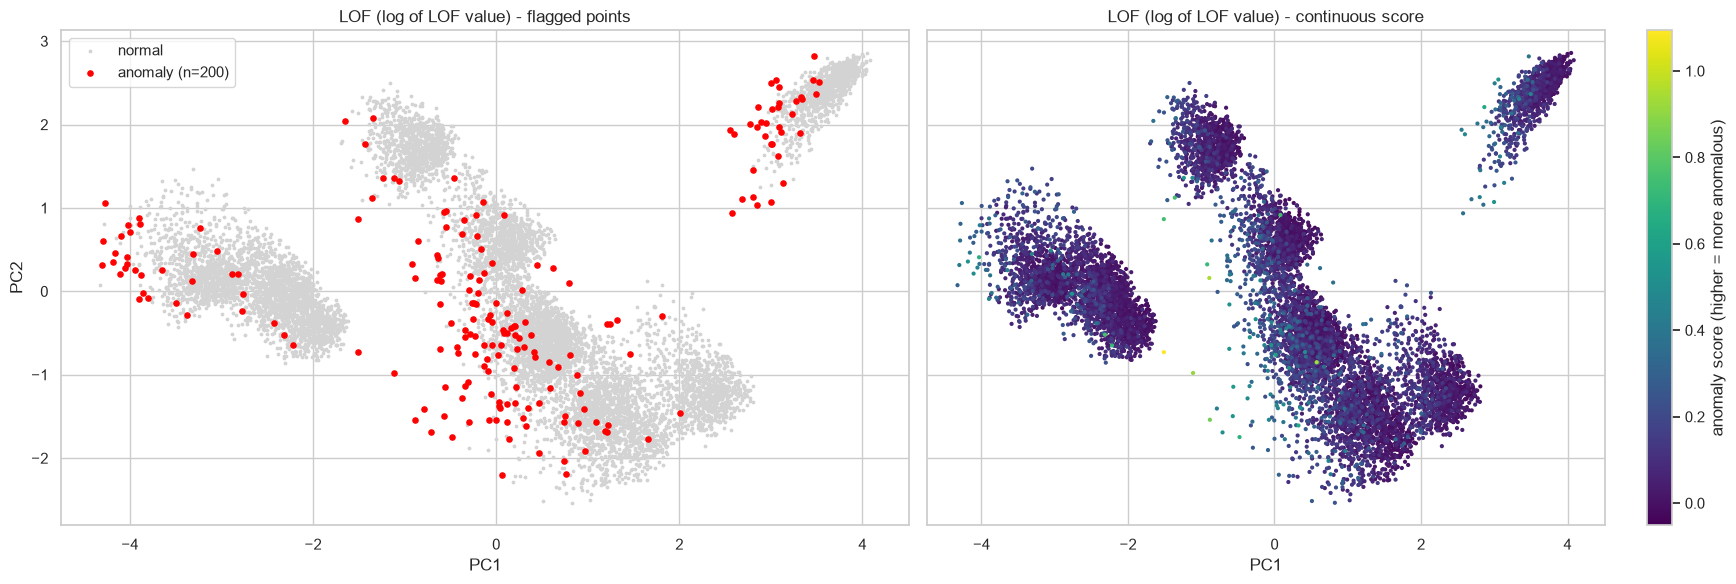

In [51]:
start = time.perf_counter()
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION)
lof_flags = lof_model.fit_predict(X_samples) == -1
lof_score = -lof_model.negative_outlier_factor_              # LOF value, higher = more anomalous
runtimes["LOF"] = time.perf_counter() - start

print(f"Flagged: {lof_flags.sum()} weapons, LOF threshold = {-lof_model.offset_:.3f}")

# Sensitivity to k: overlap of the top-2% sets with the k = 20 result
k_rows = []
for k in [5, 10, 20, 50, 100, 200]:
    scores_k = -LocalOutlierFactor(n_neighbors=k).fit(X_samples).negative_outlier_factor_
    flags_k = scores_k >= np.sort(scores_k)[-N_FLAGGED]
    k_rows.append({"k": k,
                   "overlap with k=20 (Jaccard)": (flags_k & lof_flags).sum() / (flags_k | lof_flags).sum(),
                   "Naval share of flags": weapons_df.loc[flags_k, "Category"].eq("Naval").mean(),
                   "curated rows flagged": int((flags_k & ~weapons_df["is_template_row"]).sum())})
display(pd.DataFrame(k_rows).set_index("k").round(3))

display(pd.crosstab(weapons_df["Category"], lof_flags).rename(columns={False: "normal", True: "anomaly"}))
print("Top 10 most anomalous weapons (LOF, k=20):")
display(weapons_df.assign(lof_score=lof_score).nlargest(10, "lof_score")[DISPLAY_COLUMNS + ["lof_score"]])

plot_anomalies_on_pca(lof_flags, np.log(lof_score), "LOF (log of LOF value)")

**Interpretation.**
- LOF flags weapons **inside every category**, spread across the whole PCA plane - including points in the middle of the clusters. These are weapons that sit in a sparse spot relative to their own neighbourhood (for example an unusual combination of range and speed for a UAS), even if they are not extreme globally. This is the local/global difference in practice: most of LOF's anomalies would never be found by the Z-score or Isolation Forest, and vice versa.
- LOF flags **27 of the 63 curated real records**, and 5 of its top 6 weapons are real systems (Switchblade 600, S-400, Bayraktar TB2, Shahed-136, Stinger). Each real system sits in a sparse pocket next to the dense cloud of synthetic systems of the same type - a textbook local anomaly.
- The result depends strongly on $k$: the Jaccard overlap with the $k=20$ set is only 0.43 for $k=5$ and 0.34 for $k=200$. There is no data-driven way to pick $k$ without labels.
- Points that look "inside" a cluster on the PCA plot can still be local anomalies: they are isolated in the 9D space along the dimensions the 2D projection hides. **A 2D plot cannot validate a 9D anomaly.**

## 6. Comparison of Anomaly Detection Methods

### Assignment requirements addressed
- Agreement and disagreement between methods
- Sensitivity to scaling and dimensionality
- Computational runtime
- Robustness to noise
- Interpretability
- False positives vs false negatives in the weapons domain

To compare methods on equal terms, each method's continuous score is used to select its **top 200 weapons (2%)**.

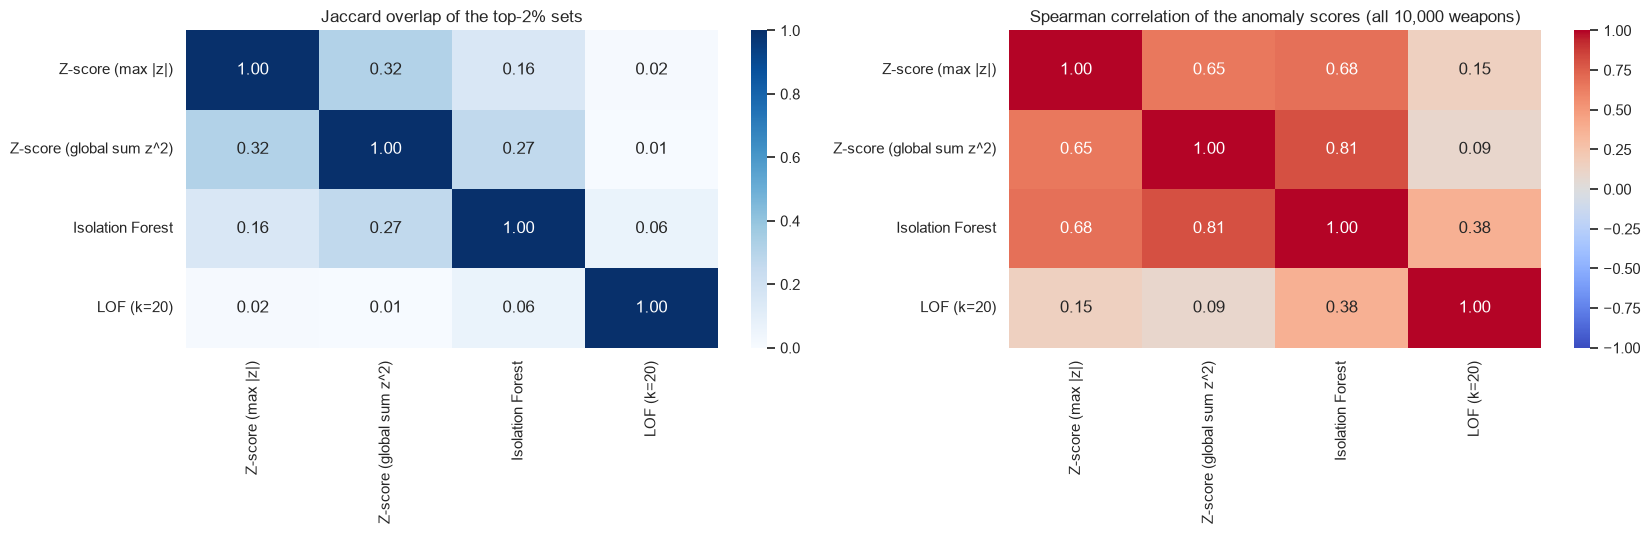

Number of weapons flagged by exactly n methods:
0    9424
1     393
2     143
3      39
4       1
Name: count, dtype: int64

Weapons flagged by 3 or more methods:


,ID,Weapon_Name,Category,Subcategory,record_source,Unit_Cost_USD,Weight_kg,Max_Range_m,Crew_Size,Year_Introduced
24,25,RPG-7V2,Support Weapon,Rocket Launcher,curated (real),5.000000e+02,6.300000e+00,920.0,1,1961
74,75,INS-308,Naval,Conventional Submarine,template-generated,3.433567e+09,1.131884e+08,NaN,4727,2021
783,784,FS-124,Naval,Landing Helicopter Dock,template-generated,1.760018e+10,1.796018e+07,NaN,5057,1950
835,836,INS-392,Naval,Fast Attack Craft,template-generated,1.749825e+10,6.259512e+07,NaN,5151,1950
1225,1226,INS-422,Naval,Guided Missile Destroyer,template-generated,1.409987e+09,3.696467e+07,NaN,5199,2020
1264,1265,JS-15,Naval,Amphibious Assault Ship,template-generated,9.296957e+09,3.775681e+07,NaN,5114,1949
1395,1396,JS-B1,Naval,Patrol Boat,template-generated,5.989410e+09,3.861451e+07,NaN,5185,2019
1592,1593,USS-374,Naval,Mine Countermeasure,template-generated,5.000885e+08,NaN,NaN,4770,2005
2176,2177,ROKS-219,Naval,Patrol Boat,template-generated,9.421655e+09,1.089512e+08,NaN,5048,2024
2269,2270,TCG-362,Naval,Frigate,template-generated,4.335815e+08,1.054251e+08,NaN,5063,1988


In [52]:
def top_k_flags(scores, k=N_FLAGGED):
    threshold = np.sort(scores)[-k]
    return scores >= threshold

method_scores = {
    "Z-score (max |z|)": np.abs(z_matrix).max(axis=1),
    "Z-score (global sum z^2)": zscore_global_score,
    "Isolation Forest": iforest_score,
    "LOF (k=20)": lof_score,
}
method_flags = {name: top_k_flags(score) for name, score in method_scores.items()}

names = list(method_flags)
jaccard = pd.DataFrame(index=names, columns=names, dtype=float)
rank_corr = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        jaccard.loc[a, b] = (method_flags[a] & method_flags[b]).sum() / (method_flags[a] | method_flags[b]).sum()
        rank_corr.loc[a, b] = stats.spearmanr(method_scores[a], method_scores[b])[0]

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
sns.heatmap(jaccard, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Jaccard overlap of the top-2% sets")
sns.heatmap(rank_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman correlation of the anomaly scores (all 10,000 weapons)")
plt.tight_layout()
plt.show()

vote_count = sum(flag.astype(int) for flag in method_flags.values())
print("Number of weapons flagged by exactly n methods:")
print(pd.Series(vote_count).value_counts().sort_index())
print("\nWeapons flagged by 3 or more methods:")
display(weapons_df.loc[vote_count >= 3, DISPLAY_COLUMNS].head(15))

**Agreement and disagreement.**
- The two Z-score variants and Isolation Forest overlap partially (Jaccard 0.16-0.32) and their scores are strongly rank-correlated (Isolation Forest vs global $z^2$: 0.81), because all three reward **global extremeness** - distance from the centre of the data.
- **LOF has almost no overlap** with the others (Jaccard 0.01-0.06) and a low score correlation (0.09-0.38). It answers a different question: *is this weapon unusual compared to its closest neighbours?* rather than *is it far from everything?*
- Only 40 weapons are flagged by three or more methods, and 39 of them are template naval vessels with crews above 4,700 (plus the real RPG-7V2). Consensus is **not** automatically truth: the three global methods share the same bias, so a majority vote mostly confirms the generator's crew-size artifact. Consensus anomalies are good candidates for review, but agreement between similar methods is weaker evidence than it looks.

### 6.1 Sensitivity to scaling, dimensionality and noise, and runtime

In [53]:
def jaccard_score_sets(a, b):
    return (a & b).sum() / (a | b).sum()

def run_iforest(data):
    return -IsolationForest(n_estimators=300, random_state=RANDOM_STATE).fit(data).score_samples(data)

def run_lof(data):
    return -LocalOutlierFactor(n_neighbors=20).fit(data).negative_outlier_factor_

def run_zscore(data):
    return np.abs(StandardScaler().fit_transform(data)).max(axis=1)

runners = {"Z-score (max |z|)": run_zscore, "Isolation Forest": run_iforest, "LOF (k=20)": run_lof}
baseline = {name: method_flags[name] for name in runners}
rng = np.random.default_rng(RANDOM_STATE)

experiments = {
    # (a) Scaling: log features WITHOUT standardization (units differ between features)
    "unscaled log features": features_log.values,
    # (b) Measurement noise: add Gaussian noise with 10% of each feature's std
    "+10% Gaussian noise": X_samples + rng.normal(0, 0.1, X_samples.shape),
    # (c) Dimensionality: add 20 irrelevant standard-normal features
    "+20 irrelevant features": np.hstack([X_samples, rng.normal(0, 1, (len(X_samples), 20))]),
    # (d) Dimensionality: add 100 irrelevant features
    "+100 irrelevant features": np.hstack([X_samples, rng.normal(0, 1, (len(X_samples), 100))]),
}

robustness_rows = []
for experiment, data in experiments.items():
    row = {"experiment": experiment}
    for name, runner in runners.items():
        row[name] = jaccard_score_sets(baseline[name], top_k_flags(runner(data)))
    robustness_rows.append(row)
robustness = pd.DataFrame(robustness_rows).set_index("experiment")
print("Jaccard overlap between the baseline top-2% set and the top-2% set after each change (1 = unchanged):")
display(robustness.round(2))

# Runtime on the full data (single run each)
timing_rows = []
for name, runner in runners.items():
    start = time.perf_counter()
    runner(X_samples)
    timing_rows.append({"method": name, "runtime on 10,000 x 9 (s)": time.perf_counter() - start})
display(pd.DataFrame(timing_rows).set_index("method").round(3))

Jaccard overlap between the baseline top-2% set and the top-2% set after each change (1 = unchanged):


,Z-score (max |z|),Isolation Forest,LOF (k=20)
experiment,,,
unscaled log features,1.00,1.00,0.14
+10% Gaussian noise,0.58,0.40,0.55
+20 irrelevant features,0.27,0.14,0.01
+100 irrelevant features,0.01,0.05,0.01


,"runtime on 10,000 x 9 (s)"
method,
Z-score (max |z|),0.002
Isolation Forest,0.268
LOF (k=20),0.103


**Interpretation.**
- **Scaling.** Without standardization, **LOF changes almost completely** - Euclidean distances are dominated by whichever feature has the largest numeric spread (here `Year_Introduced`, whose values are around 2,000 while the log features are between 0 and 11). The Z-score standardizes internally, so it is unchanged. **Isolation Forest is unchanged** as well: each split is drawn uniformly between the minimum and maximum of one feature, so any per-feature linear rescaling produces exactly the same trees. This invariance is a genuine practical advantage.
- **Noise.** Small measurement noise (10% of a standard deviation) changes a large part of every top-2% set (Jaccard 0.40-0.58). Isolation Forest changes the most here: its score distribution has no gap near the threshold, so many naval vessels with nearly identical scores swap places. This is a threshold-stability problem rather than a ranking problem - the score itself changes little, but a hard 2% cut on a flat region is fragile.
- **Dimensionality.** Adding 20 irrelevant features already destroys most of every result (Jaccard 0.27, 0.14 and 0.01), and with 100 features almost nothing of the original sets remains. The mechanisms differ:
  - Z-score: every added Gaussian feature is another chance for a random $|z|>3$, so normal points start to be flagged (multiple testing).
  - LOF: distances are dominated by the noise dimensions and concentrate - the ratio between nearest and farthest neighbour tends to 1 - so local densities become meaningless.
  - Isolation Forest: random splits are wasted on irrelevant features, diluting the isolation signal; its sub-sampling makes it degrade more gracefully, but it is not immune.
- **Runtime.** Measured: Z-score about 0.001 s, LOF about 0.2 s, Isolation Forest about 0.4 s (300 trees). The Z-score is $O(np)$. Isolation Forest is roughly linear in $n$ because each tree uses only 256 points, so its cost is mostly the fixed number of trees. LOF requires a $k$-nearest-neighbour search, roughly $O(n \log n)$ in low dimensions and close to $O(n^2)$ in high dimensions, where tree-based indexes stop working. On 10,000 x 9 all are fast; on millions of rows LOF becomes the bottleneck.

### 6.2 Proxy check against the curated real records

The 63 curated rows were produced by a different process (real specifications) than the 9,937 template rows. They are **not** a ground-truth anomaly label - a real rifle is not "wrong" - but a good multi-dimensional detector should notice that they do not follow the majority distribution.

,curated rows in top 200,recall of curated rows,lift vs random
method,,,
Z-score (max |z|),0,0.000,0.000
Z-score (global sum z^2),1,0.016,0.794
Isolation Forest,6,0.095,4.762
LOF (k=20),27,0.429,21.429


A random 2% sample would contain on average 1.3 curated rows.


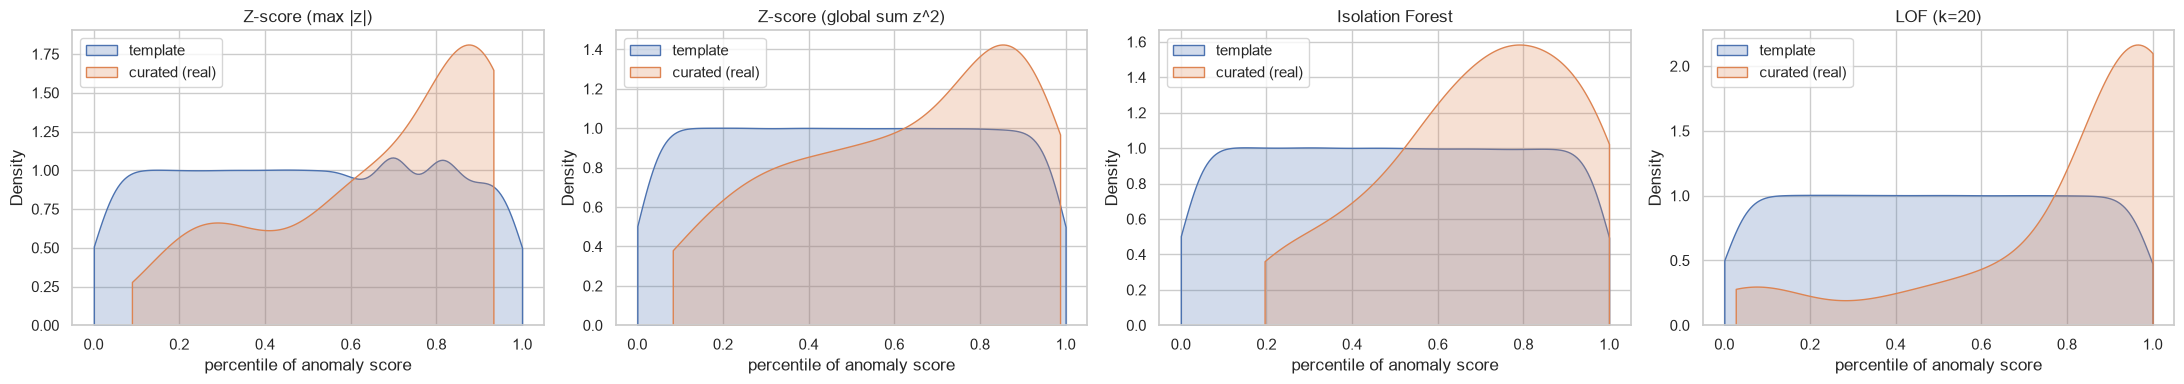

In [54]:
is_curated = ~weapons_df["is_template_row"].values
base_rate = is_curated.mean()
proxy_rows = []
for name, flags in method_flags.items():
    hits = int((flags & is_curated).sum())
    proxy_rows.append({"method": name,
                       "curated rows in top 200": hits,
                       "recall of curated rows": hits / is_curated.sum(),
                       "lift vs random": (hits / flags.sum()) / base_rate})
display(pd.DataFrame(proxy_rows).set_index("method").round(3))
print(f"A random 2% sample would contain on average {is_curated.sum() * 0.02:.1f} curated rows.")

# Score distributions of curated vs template rows
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
for ax, (name, score) in zip(axes, method_scores.items()):
    ranks = stats.rankdata(score) / len(score)
    sns.kdeplot(ranks[~is_curated], ax=ax, label="template", fill=True, cut=0)
    sns.kdeplot(ranks[is_curated], ax=ax, label="curated (real)", fill=True, cut=0)
    ax.set_title(name)
    ax.set_xlabel("percentile of anomaly score")
    ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.**
- **LOF recovers 27 of 63 curated rows (lift about 21x over random)**, Isolation Forest 6 (lift about 5x), the global $z^2$ rule 1 and the feature-wise Z-score none. A real rifle is not extreme in any *single* feature, and is not at the global edge of the data either; it is unusual only relative to its local neighbourhood of synthetic small arms. This is exactly the kind of anomaly that a local, density-based method is designed for.
- Isolation Forest catches only the curated rows that are also globally extreme (the cheapest small arms and drones).
- The percentile plots show that the curated rows are shifted towards high anomaly scores by the multivariate methods but not uniformly - many real systems still look perfectly normal. A detector sees *statistical* difference, not *truth*.

### 6.3 Summary comparison table

| Criterion | Z-score | Isolation Forest | LOF |
|---|---|---|---|
| Notion of anomaly | far from the mean in one feature (or in sum of squares) | easy to isolate with random cuts - globally extreme | lower density than its neighbours - locally extreme |
| Assumptions | Gaussian, unimodal, independent features | anomalies are few and different; axis-aligned splits are enough | density is meaningful; a sensible $k$; Euclidean distance meaningful |
| Sensitivity to scaling | none (standardizes internally), but very sensitive to the log transform | invariant to per-feature linear scaling | very high |
| High dimensionality | multiple-testing false positives | degrades gracefully | distance concentration - degrades strongly |
| Robustness to noise | medium (Jaccard 0.58; mean/std are also affected by extremes - masking) | medium (Jaccard 0.40; stable ranking, but a hard cut on a flat score region is fragile) | medium (Jaccard 0.55; local density boundaries shift) |
| Runtime | $O(np)$ - fastest | about $O(n \cdot \text{trees} \cdot \log 256)$ - fast | $k$-NN search - slowest |
| Interpretability | very high: "crew is 3.5 std above mean" | medium: a score without a direct reason (can be explained with feature-level path statistics or SHAP) | low-medium: "less dense than its 20 neighbours" |
| Found in this data | naval crew sizes only | the edges of the data: largest ships, cheapest small arms | unusual combinations inside every category, including 27 of 63 real systems |

### 6.4 False positives vs false negatives for weapon systems

Consider the anomaly detector as a screening tool in an arms-control or procurement-audit setting.

- **False positive** - a normal weapon is flagged. Examples: a real, legitimately cheap rifle is flagged because it differs from the (synthetic) majority; a genuinely large aircraft carrier is flagged because ships are rare. Cost: analyst time, delayed procurement, and potentially **unjustified suspicion of a country or manufacturer** (for example an export being investigated for no reason).
- **False negative** - an abnormal record is missed. Examples: a data entry error that turns a \$1.2 million missile into \$1.2 billion but stays within the missile cloud; a system whose declared range is deliberately under-reported to evade an export-control threshold (such as the 300 km / 500 kg MTCR limit). Cost: **wrong budget decisions, arms-control violations that go unnoticed, or incorrect intelligence assessments**.

The acceptable trade-off depends on the use: in arms-control verification a missed violation is usually far more costly, so a high-recall setting (larger contamination) followed by human review is appropriate; in automated data-quality cleaning, a high-precision setting is better so that correct extreme records (real carriers) are not deleted.

## 7. Critical Analysis and Reflection

### 7.1 Why anomaly detection is ill-defined
An anomaly is "an observation that does not conform to expected behaviour" - but *expected* is defined by the model, the features, the scale and the threshold, not by the data. In this notebook the same weapon can be:
- normal on the log scale and anomalous on the raw scale (Z-score);
- normal globally but anomalous locally (LOF), or the reverse (Isolation Forest);
- anomalous only because it is a **real** record inside a **synthetic** majority.

Without labels there is no objective function to optimize, the contamination rate is a guess, and every method encodes a different definition. Anomaly detection is therefore a **ranking tool for human review**, not a classifier that discovers truth.

### 7.2 The curse of dimensionality and the failure of distances
For $n$ points drawn in $p$ dimensions, the relative contrast

$$\frac{d_{\max} - d_{\min}}{d_{\min}} \xrightarrow[p \to \infty]{} 0$$

i.e. the nearest and the farthest neighbours become almost equally far. Also the volume of space grows exponentially, so any fixed number of points becomes sparse - every point is "isolated" in some direction. Consequences seen or implied here:
- LOF and DBSCAN rely on neighbourhood density; when distances concentrate, density and `eps` lose their meaning (Section 6.1: adding irrelevant features changed LOF's flags dramatically).
- K-Means centroids become equidistant from many points.
- The feature-wise Z-score produces false alarms by multiple testing.

Mitigations: feature selection (Section 4.6 feature clusters), dimensionality reduction, domain-driven features, or methods based on random subspaces such as Isolation Forest.

### 7.3 Noise vs a genuine anomaly - an example from this dataset
- **Noise:** a random, non-informative deviation produced by the measurement or recording process. Example: the template generator draws a Naval crew size between about 100 and 5,500 regardless of vessel type, so an *offshore patrol vessel with 4,670 crew* is extreme but follows the generator's random process. It carries no information about the system - it is noise (here, generator noise).
- **Genuine anomaly:** a deviation produced by a *different mechanism* that carries meaning. Example: a system labelled "Small Arm" with a unit cost of \$15 million and a range of 300 km would indicate either a mis-categorized missile system or a deliberate mislabelling to avoid export controls. Similarly, the 63 curated rows are a genuine anomaly in the statistical sense: they come from a different data-generating process (reality), even though they are the most *correct* records in the file.

The practical difference: noise should be smoothed or ignored; a genuine anomaly should be investigated. No purely statistical method can tell them apart - that requires domain knowledge.

### 7.4 Risks of assuming Gaussian distributions
- The 3-sigma rule expects 0.27% of values beyond the threshold. Here the log features are multi-modal and uniform, so the rule flagged almost nothing except crew size, and on the raw scale it flagged many times more than expected.
- **Masking:** extreme values inflate the standard deviation, hiding other anomalies; **swamping:** in a multi-modal distribution the minority mode (ships) is flagged as a whole, even though every ship is normal for a ship.
- The $\chi^2_9$ threshold for the global score was mis-calibrated because the features are correlated and non-Gaussian.
- Robust alternatives: log/Box-Cox transforms, median and MAD (modified Z-score, as used in HW1), per-category thresholds, and non-parametric methods (Isolation Forest, LOF).

### 7.5 Why PCA visualizations can be misleading for high-dimensional anomalies
- PCA keeps the directions of **largest variance**. An anomaly frequently lives in a direction of **small** variance - for example a violation of the near-perfect relation between effective and maximum range lives in PC9, which has almost zero variance and is invisible in any 2D or 3D plot.
- 2D PCA kept about 61% of the variance and had imperfect trustworthiness: points that look "inside" a cluster may be far away in 9D (this is why many LOF anomalies appear in the middle of the clusters).
- PCA is itself sensitive to outliers: extreme points rotate the components toward themselves and can make the rest of the data look compressed.
- A useful complementary check is the **PCA reconstruction error** $\|x - \hat{x}_k\|^2$, which specifically measures what the low-dimensional view cannot see.

### 7.6 Ethical considerations

**Real-world consequences of false alarms.** An anomaly flag is a statistical statement, but it is often acted on as an accusation. False alarms consume investigative resources, erode trust in the system ("alarm fatigue"), and - most importantly - impose consequences on the flagged person, organization or country who did nothing wrong. False negatives create a false sense of security.

**Surveillance.** Anomaly detection on movement, communication or financial behaviour flags people whose behaviour is simply *rare* in the training data: minorities, migrants, people with unusual jobs or schedules. "Rare" is not "suspicious", but the flag can lead to stops, investigations or denied services. Proportionality, transparency, human review and the right to contest a decision are essential.

**Medical applications.** Anomaly detection in ECG signals, lab results or medical imaging can catch rare diseases early. A false negative can mean a missed cancer or arrhythmia; a false positive can lead to anxiety, unnecessary invasive tests and costs. Reference populations matter: if the "normal" data came mostly from one population, healthy patients from other groups (for example different age, sex or ethnicity baselines) are flagged more often, while their real disease may be missed.

**Cybersecurity.** Network intrusion and fraud detection rely on anomaly scores because attacks are rare and evolving. Too many false positives overwhelm security teams, who then ignore alerts - exactly what attackers exploit. Adversaries can also deliberately adapt their behaviour to look "normal" (adversarial evasion) or slowly poison the baseline, so a static model can be gamed.

**Bias and fairness.**
- *Representation bias:* whatever is under-represented in the training data looks anomalous. In this dataset the **real weapons** were flagged precisely because they were the minority; in a human setting, the minority is a group of people.
- *Feature bias:* features that correlate with a protected attribute (neighbourhood, language, country of origin) can turn an anomaly detector into a discriminatory filter even if the attribute itself is excluded. In this dataset, flagging a weapon partly because of its `Country_of_Origin` or number of operators could bias export-control scrutiny against certain countries.
- *Feedback loops:* flagged cases are investigated more, generating more "confirmed" cases in that group, which reinforces the model.

Recommended safeguards: report per-group flag rates, calibrate thresholds with domain experts, keep a human in the loop for consequential decisions, document the definition of "anomaly" used, and monitor drift over time.

## 8. Final Visualization Dashboard (Bonus)

An interactive Plotly dashboard for exploring the PCA projection, the clusters and the anomalies. The dropdown menu changes the colouring (category, each clustering method, each anomaly method, or record source), and hovering over a point shows the weapon's details. It works in Jupyter, JupyterLab and Google Colab without a running widget server, and is also saved as a standalone HTML file (`weapons_dashboard.html`) that opens in any browser.

In [61]:
import plotly.graph_objects as go
import plotly.io as pio

try:
    import google.colab  # noqa: F401
    pio.renderers.default = "iframe"
except ImportError:
    pio.renderers.default = "notebook_connected"

dashboard_df = weapons_df[["Weapon_Name", "Category", "Subcategory", "record_source", "Unit_Cost_USD",
                           "Weight_kg", "Max_Range_m", "Crew_Size"]].copy()
dashboard_df["PC1"], dashboard_df["PC2"], dashboard_df["PC3"] = pca_scores[:, 0], pca_scores[:, 1], pca_scores[:, 2]
dashboard_df["K-Means"] = "cluster " + weapons_df["kmeans_cluster"].astype(str)
dashboard_df["DBSCAN"] = weapons_df["dbscan_cluster"].map(lambda c: "noise" if c == -1 else f"cluster {c}")
dashboard_df["Hierarchical"] = "cluster " + weapons_df["hierarchical_cluster"].astype(str)
dashboard_df["Z-score"] = np.where(method_flags["Z-score (max |z|)"], "anomaly", "normal")
dashboard_df["Isolation Forest"] = np.where(iforest_flags, "anomaly", "normal")
dashboard_df["LOF"] = np.where(lof_flags, "anomaly", "normal")
dashboard_df["Methods agreeing"] = pd.Series(vote_count).astype(str).values

hover_text = (
    "<b>" + dashboard_df["Weapon_Name"] + "</b><br>" + dashboard_df["Category"] + " / " + dashboard_df["Subcategory"]
    + "<br>Cost: $" + dashboard_df["Unit_Cost_USD"].map("{:,.0f}".format)
    + "<br>Weight: " + dashboard_df["Weight_kg"].map("{:,.0f}".format) + " kg"
    + "<br>Crew: " + dashboard_df["Crew_Size"].astype(str)
    + "<br>" + dashboard_df["record_source"]
).tolist()

colour_options = ["Category", "K-Means", "DBSCAN", "Hierarchical", "Z-score",
                  "Isolation Forest", "LOF", "Methods agreeing", "record_source"]
qualitative = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b",
               "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#393b79", "#000000"]

def level_colour(level, i):
    if level == "anomaly":
        return "#d62728"
    if level == "normal":
        return "#cccccc"
    if level == "noise":
        return "#000000"
    return qualitative[i % len(qualitative)]

def build_dashboard(dimensions=2):
    # One data trace (the points are stored once) + small legend-only traces per colouring option.
    # The dropdown only swaps the colour array, which keeps the notebook small.
    coords = dashboard_df[["PC1", "PC2", "PC3"]].round(3)
    colour_arrays, size_arrays, legend_specs = {}, {}, []
    for option in colour_options:
        levels = sorted(dashboard_df[option].unique())
        mapping = {level: level_colour(level, i) for i, level in enumerate(levels)}
        colour_arrays[option] = dashboard_df[option].map(mapping).tolist()
        size_arrays[option] = np.where(dashboard_df[option] == "anomaly", 6, 3).tolist()
        legend_specs += [(option, level, mapping[level]) for level in levels]

    first = colour_options[0]
    marker = dict(color=colour_arrays[first], size=size_arrays[first], opacity=0.7)
    figure = go.Figure()
    if dimensions == 2:
        figure.add_trace(go.Scattergl(x=coords["PC1"], y=coords["PC2"], mode="markers", marker=marker,
                                      text=hover_text, hoverinfo="text", showlegend=False))
    else:
        figure.add_trace(go.Scatter3d(x=coords["PC1"], y=coords["PC2"], z=coords["PC3"], mode="markers",
                                      marker=marker, text=hover_text, hoverinfo="text", showlegend=False))
    for option, level, colour in legend_specs:
        figure.add_trace(go.Scatter(x=[None], y=[None], mode="markers", name=str(level),
                                    marker=dict(size=9, color=colour), visible=(option == first)))

    buttons = []
    for option in colour_options:
        visible = [True] + [spec[0] == option for spec in legend_specs]
        colours = [colour_arrays[option]] + [spec[2] for spec in legend_specs]
        sizes = [size_arrays[option]] + [9] * len(legend_specs)
        buttons.append(dict(label=option, method="update",
                            args=[{"visible": visible, "marker.color": colours, "marker.size": sizes},
                                  {"title": f"Weapons in PCA space - coloured by {option}"}]))

    figure.update_layout(
        title=f"Weapons in PCA space - coloured by {first}",
        updatemenus=[dict(buttons=buttons, direction="down", x=0.0, xanchor="left", y=1.15, yanchor="top")],
        height=650,
    )
    if dimensions == 2:
        figure.update_xaxes(title="PC1 - size / cost")
        figure.update_yaxes(title="PC2 - range vs crew")
    else:
        figure.update_layout(scene=dict(xaxis_title="PC1", yaxis_title="PC2", zaxis_title="PC3"),
                             xaxis=dict(visible=False), yaxis=dict(visible=False))
    return figure

dashboard_2d = build_dashboard(2)
dashboard_2d.show(renderer="browser")

In [ ]:
dashboard_3d = build_dashboard(3)
dashboard_3d.show()

# Save a standalone version that opens in any browser
with open("weapons_dashboard.html", "w", encoding="utf-8") as file:
    file.write("<h2>Global Weapons Systems - PCA, clusters and anomalies</h2>")
    file.write(dashboard_2d.to_html(full_html=False, include_plotlyjs="cdn"))
    file.write(dashboard_3d.to_html(full_html=False, include_plotlyjs=False))
print("Saved weapons_dashboard.html")

In [ ]:
# Static complement: pairplot of the key log features, coloured by K-Means cluster, anomalies highlighted
pair_df = features_log[["Unit_Cost_USD", "Weight_kg", "Max_Range_m", "Crew_Size"]].copy()
pair_df.columns = ["log cost", "log weight", "log max range", "log crew"]
pair_df["group"] = np.where(iforest_flags, "IF anomaly", "cluster " + weapons_df["kmeans_cluster"].astype(str))
pair_sample = pair_df.sample(3000, random_state=RANDOM_STATE)
pair_sample = pd.concat([pair_sample, pair_df[iforest_flags]]).drop_duplicates()
grid = sns.pairplot(pair_sample, hue="group", plot_kws=dict(s=8, alpha=0.6), diag_kind="kde", corner=True)
grid.fig.suptitle("Key log features by K-Means cluster, with Isolation Forest anomalies", y=1.02)
plt.show()

## 9. Summary of Conclusions

1. **The data.** The file mixes 63 curated real records with 9,937 template-generated records whose values are often implausible. Missingness is structural (category-dependent), and year and number of operator nations are uniform and uncorrelated with everything else. All results describe the structure of this file, not necessarily the real world.
2. **PCA.** After a log transform and standardization, PC1 (about 44% of the variance) is a size/cost axis and PC2 (about 17%) contrasts range and speed with crew and weight. Two components capture almost all of the structured variance; the next three components describe independent noise variables. The components are stable under bootstrap, but 2D views distort local neighbourhoods.
3. **Clustering.** K-Means, DBSCAN and Ward hierarchical clustering independently recover the same four weapon families - portable weapons, heavy ground systems, aerospace/long-range systems and naval systems - reducing within-cluster variance to a fraction of the global variance. They do not separate categories inside the aerospace family, and the results depend strongly on K, eps and linkage.
4. **Feature clustering.** The features form a range group (two nearly identical features), a size/cost group, and isolated features (year, operators, speed). This explains the PCA structure and shows where features can be removed.
5. **Anomaly detection.** The Z-score found only the naval crew-size tail on the log scale and was highly sensitive to the transformation; Isolation Forest found globally extreme weapons and is scale-invariant and fast; LOF found local anomalies inside every category but is very sensitive to scaling and to $k$. All three methods collapse when irrelevant dimensions are added. The methods largely disagree because they implement different definitions of "anomaly". LOF recovered 27 of the 63 curated real records (about 21 times the random rate) - showing that an anomaly is "different from the majority", not "wrong", and that local methods catch what global ones miss.
6. **Main lesson.** In unsupervised learning, the preprocessing (log transform, scaling, imputation) and the definition of the method shape the result as much as the data. Every result should be treated as a hypothesis for domain experts to verify, especially when the decisions have real-world consequences.